# Project : Predicting Customer Purchase Behavior

**Objective:** Predict whether a customer will make a purchase based on browsing history.


## Dataset Summary

**Source file:** customer_purchase_data.csv  
**Rows:** 1501  
**Columns:** 9

**Features**
- Age (numeric)
- Gender (binary encoded: 0/1)
- AnnualIncome (numeric)
- NumberOfPurchases (numeric)
- ProductCategory (categorical encoded as integers)
- TimeSpentOnWebsite (numeric)
- LoyaltyProgram (binary encoded: 0/1)
- DiscountsAvailed (numeric)

**Target**
- PurchaseStatus (binary encoded: 0/1)


## Feature Effects (Expected)

These are general, model-agnostic expectations about how each feature could influence `PurchaseStatus`.

- **Age:** Purchase likelihood may vary by life stage; mid-age users often have more purchasing power, while younger or older segments may purchase less depending on product fit.
- **Gender (0/1):** May capture preference differences across categories or marketing alignment; the effect depends on the product mix.
- **AnnualIncome:** Higher income generally increases purchase probability, especially for higher-priced items.
- **NumberOfPurchases:** Strong positive signal; prior buying behavior is often the best predictor of future purchases.
- **ProductCategory (encoded):** Different categories convert at different rates; some categories are more impulsive or higher intent.
- **TimeSpentOnWebsite:** More time typically indicates higher intent, though very long times can also reflect indecision.
- **LoyaltyProgram (0/1):** Members often purchase more due to incentives and higher engagement.
- **DiscountsAvailed:** Discounts can increase conversion; frequent discount use may also indicate price sensitivity.

Use model coefficients or feature importance later to validate these assumptions.


In [98]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt




df=pd.read_csv("customer_purchase_data.csv")


In [99]:
df.head(20)

,Age,Gender,AnnualIncome,NumberOfPurchases,ProductCategory,TimeSpentOnWebsite,LoyaltyProgram,DiscountsAvailed,PurchaseStatus
0,40,1,66120.267939,8,0,30.568601,0,5,1
1,20,1,23579.773583,4,2,38.240097,0,5,0
2,27,1,127821.306432,11,2,31.633212,1,0,1
3,24,1,137798.623120,19,3,46.167059,0,4,1
4,31,1,99300.964220,19,1,19.823592,0,0,1
5,66,1,37758.117475,14,4,17.827493,0,2,0
6,39,1,126883.385286,16,3,42.085384,1,4,1
7,64,1,39707.359724,13,2,17.190292,1,0,0
8,43,0,102797.301269,20,1,6.023475,0,3,0
9,20,1,63854.921080,16,0,38.572466,0,5,1


In [100]:
df.tail()

,Age,Gender,AnnualIncome,NumberOfPurchases,ProductCategory,TimeSpentOnWebsite,LoyaltyProgram,DiscountsAvailed,PurchaseStatus
1495,39,1,65048.141834,13,0,34.590743,0,5,1
1496,67,1,28775.331069,18,2,17.625707,0,1,1
1497,40,1,57363.247541,7,4,12.206033,0,0,0
1498,63,0,134021.775532,16,2,37.311634,1,0,1
1499,50,0,52625.665974,13,0,25.348017,1,4,1


In [101]:
df.describe()

,Age,Gender,AnnualIncome,NumberOfPurchases,ProductCategory,TimeSpentOnWebsite,LoyaltyProgram,DiscountsAvailed,PurchaseStatus
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.00000
mean,44.298667,0.504667,84249.164338,10.420000,2.012667,30.469040,0.326667,2.555333,0.43200
std,15.537259,0.500145,37629.493078,5.887391,1.428005,16.984392,0.469151,1.705152,0.49552
min,18.000000,0.000000,20001.512518,0.000000,0.000000,1.037023,0.000000,0.000000,0.00000
25%,31.000000,0.000000,53028.979155,5.000000,1.000000,16.156700,0.000000,1.000000,0.00000
50%,45.000000,1.000000,83699.581476,11.000000,2.000000,30.939516,0.000000,3.000000,0.00000
75%,57.000000,1.000000,117167.772858,15.000000,3.000000,44.369863,1.000000,4.000000,1.00000
max,70.000000,1.000000,149785.176481,20.000000,4.000000,59.991105,1.000000,5.000000,1.00000


In [102]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 1500 non-null   int64  
 1   Gender              1500 non-null   int64  
 2   AnnualIncome        1500 non-null   float64
 3   NumberOfPurchases   1500 non-null   int64  
 4   ProductCategory     1500 non-null   int64  
 5   TimeSpentOnWebsite  1500 non-null   float64
 6   LoyaltyProgram      1500 non-null   int64  
 7   DiscountsAvailed    1500 non-null   int64  
 8   PurchaseStatus      1500 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 105.6 KB


In [103]:
df.isnull().sum()

Age                   0
Gender                0
AnnualIncome          0
NumberOfPurchases     0
ProductCategory       0
TimeSpentOnWebsite    0
LoyaltyProgram        0
DiscountsAvailed      0
PurchaseStatus        0
dtype: int64

In [104]:
df.duplicated().sum()

np.int64(112)

In [105]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [106]:
df.shape

(1388, 9)

# Feature Classification
- Qualitative (categorical) vs Quantitative (numeric) features

In [107]:
# Classify features into qualitative and quantitative
qualitative_features = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
quantitative_features = df.select_dtypes(include=['number']).columns.tolist()

print("Qualitative (Categorical) Features:")
print(qualitative_features)
print("\nQuantitative (Numeric) Features:")
print(quantitative_features)

Qualitative (Categorical) Features:
[]

Quantitative (Numeric) Features:
['Age', 'Gender', 'AnnualIncome', 'NumberOfPurchases', 'ProductCategory', 'TimeSpentOnWebsite', 'LoyaltyProgram', 'DiscountsAvailed', 'PurchaseStatus']


# Classification of Level of Data
- Nominal, Ordinal, Interval, Ratio

In [108]:
# Classify features into nominal, ordinal, interval, ratio
cols = df.columns.tolist()

# Suggested mapping (edit these lists to match your dataset)
nominal_candidates = ['Gender', 'ProductCategory', 'LoyaltyProgram', 'PurchaseStatus']
ordinal_candidates = []  # no ordinal features in current dataset
interval_candidates = []  # e.g., temperature in Celsius
ratio_candidates = ['Age', 'AnnualIncome', 'TimeSpentOnWebsite', 'NumberOfPurchases', 'DiscountsAvailed']

nominal = [c for c in nominal_candidates if c in cols]
ordinal = [c for c in ordinal_candidates if c in cols]
interval = [c for c in interval_candidates if c in cols]
ratio = [c for c in ratio_candidates if c in cols]

assigned = set(nominal + ordinal + interval + ratio)
remaining = [c for c in cols if c not in assigned]

# Heuristic for remaining numeric-only columns
numeric_cols = df.select_dtypes(include=['number']).columns
for c in remaining:
    if c in numeric_cols:
        unique_count = df[c].nunique(dropna=True)
        if unique_count <= 2:
            nominal.append(c)
        elif unique_count <= 10:
            ordinal.append(c)  # treat small integer-coded sets as ordinal by default
        else:
            ratio.append(c)

# Final lists
print("Nominal:", nominal)
print("Ordinal:", ordinal)
print("Interval:", interval)
print("Ratio:", ratio)

# Show any non-numeric leftovers (if any)
non_numeric_leftovers = [c for c in remaining if c not in numeric_cols]
if non_numeric_leftovers:
    print("\nNon-numeric columns not classified:", non_numeric_leftovers)

Nominal: ['Gender', 'ProductCategory', 'LoyaltyProgram', 'PurchaseStatus']
Ordinal: []
Interval: []
Ratio: ['Age', 'AnnualIncome', 'TimeSpentOnWebsite', 'NumberOfPurchases', 'DiscountsAvailed']


In [109]:
# Descriptive analysis: mean, median, mode, Q1, Q2, Q3
num_df = df.select_dtypes(include=['number'])

mean_vals = num_df.mean()
median_vals = num_df.median()
mode_vals = num_df.mode().iloc[0]
q1_vals = num_df.quantile(0.25)
q2_vals = num_df.quantile(0.50)
q3_vals = num_df.quantile(0.75)

summary_stats = pd.DataFrame({
    'mean': mean_vals,
    'median': median_vals,
    'mode': mode_vals,
    'Q1': q1_vals,
    'Q2': q2_vals,
    'Q3': q3_vals
})

summary_stats

,mean,median,mode,Q1,Q2,Q3
Age,43.939481,44.000000,50.000000,30.750000,44.000000,57.000000
Gender,0.501441,1.000000,1.000000,0.000000,1.000000,1.000000
AnnualIncome,84699.045444,84625.292873,20001.512518,53766.895806,84625.292873,117188.207975
NumberOfPurchases,10.548991,11.000000,14.000000,6.000000,11.000000,15.000000
ProductCategory,2.002882,2.000000,1.000000,1.000000,2.000000,3.000000
TimeSpentOnWebsite,30.747545,31.213146,1.037023,16.379635,31.213146,44.666368
LoyaltyProgram,0.333573,0.000000,0.000000,0.000000,0.000000,1.000000
DiscountsAvailed,2.609510,3.000000,4.000000,1.000000,3.000000,4.000000
PurchaseStatus,0.466859,0.000000,0.000000,0.000000,0.000000,1.000000


# Feature Distribution
- For Numeric Features

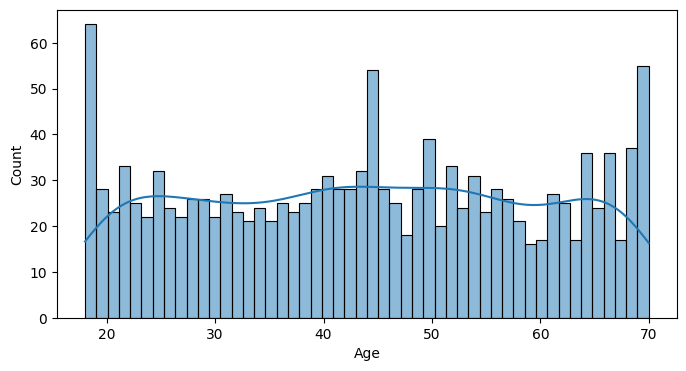

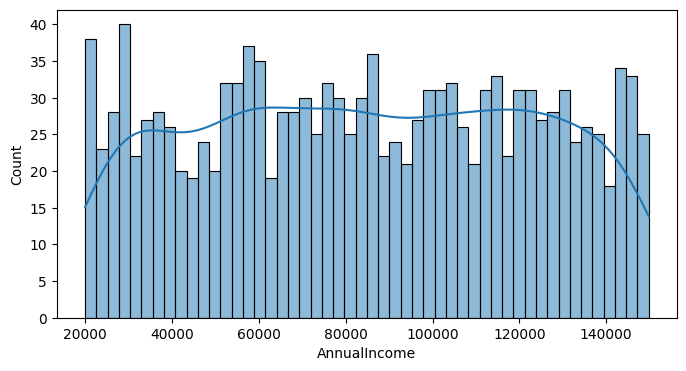

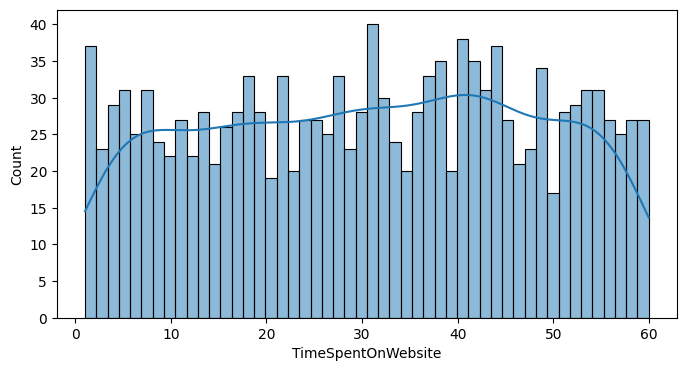

In [110]:
cols=[ 'Age','AnnualIncome','TimeSpentOnWebsite']
for c in cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[c],kde=True,bins=50)





In [111]:

# cols=[ 'Age','AnnualIncome','TimeSpentOnWebsite']
# for c in cols:
#     df[cols] = np.log(df[cols])


# for c in cols:
#     plt.figure(figsize=(8, 4))
#     sns.histplot(df[c],kde=True,bins=50)


- For Catagorical Features

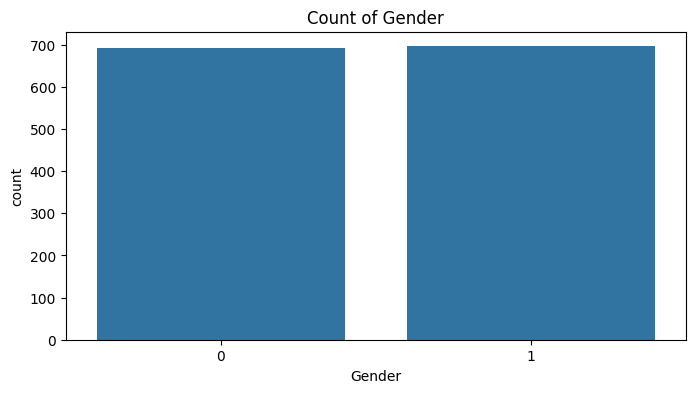

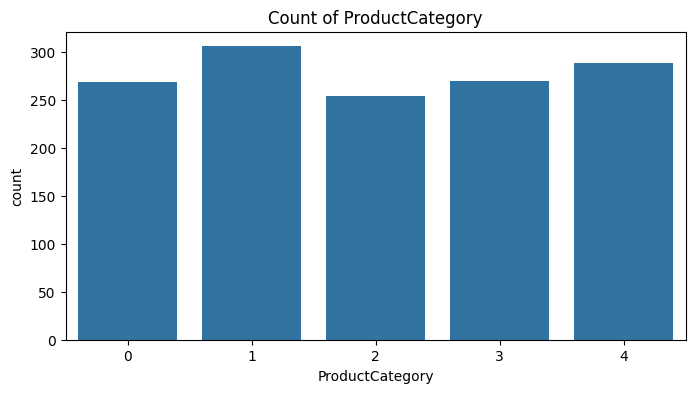

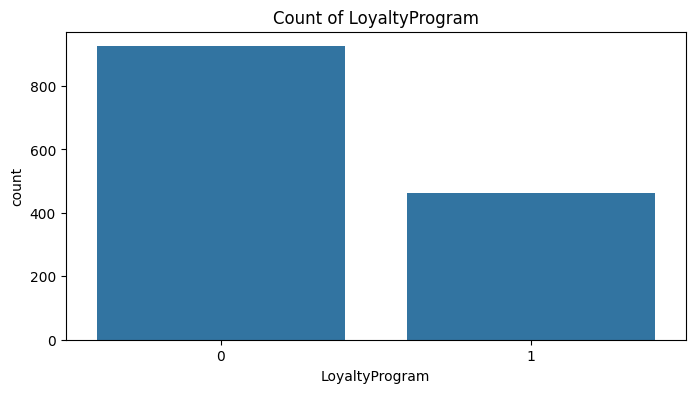

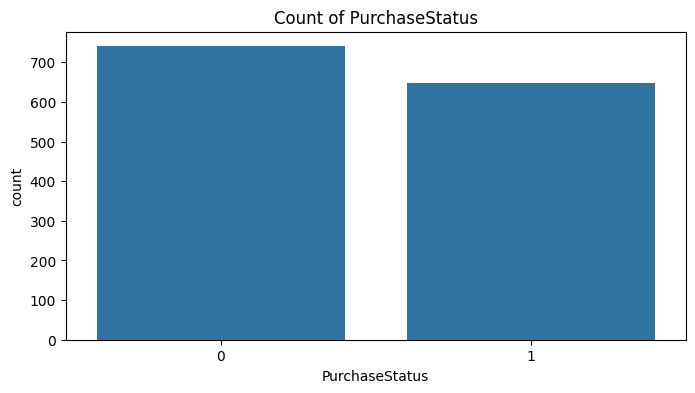

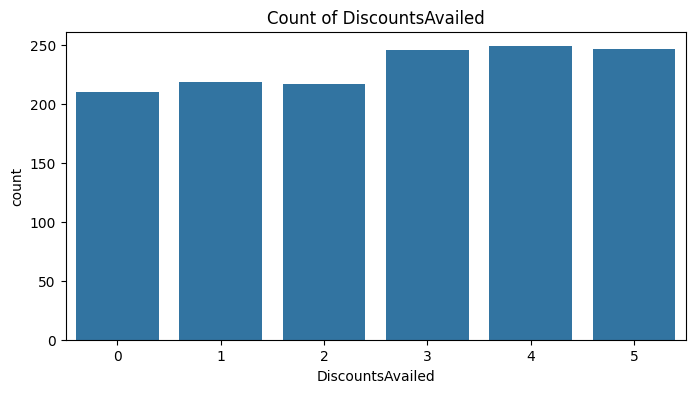

In [112]:
categorical_cols=['Gender','ProductCategory','LoyaltyProgram','PurchaseStatus','DiscountsAvailed']
for c in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=df[c])
    plt.title(f'Count of {c}')
    plt.show()

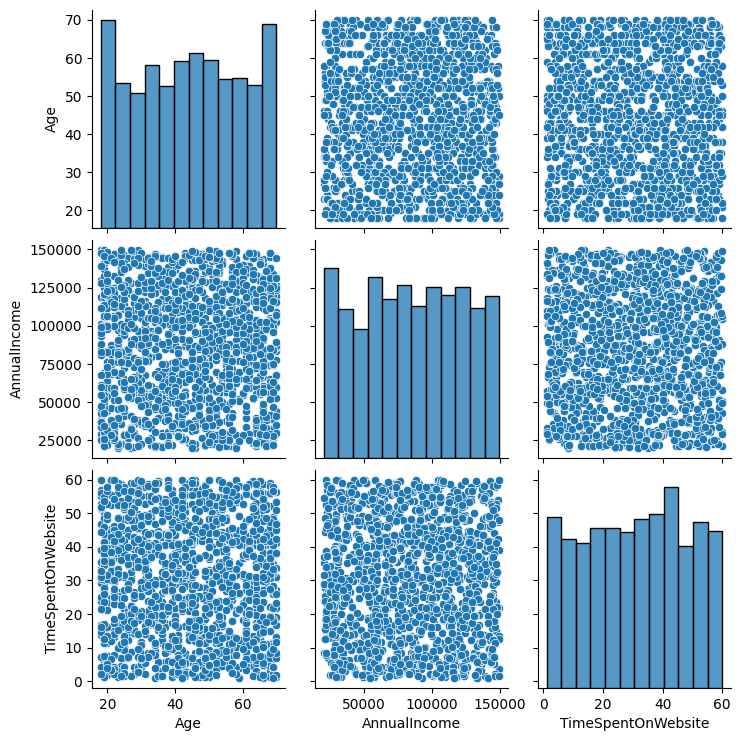

In [113]:

# palette = {1: 'blue', 0: 'orange'}
sns.pairplot(df[['Age','AnnualIncome','TimeSpentOnWebsite']]
             )
plt.grid()
plt.show()

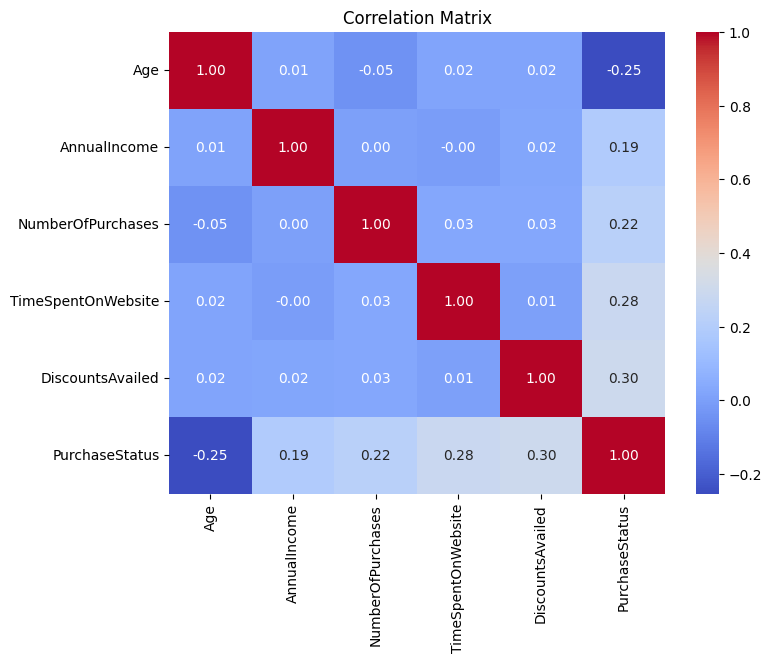

In [114]:


# Only numerical columns
numerical_cols = ['Age','AnnualIncome','NumberOfPurchases','TimeSpentOnWebsite','DiscountsAvailed','PurchaseStatus']

# Correlation matrix
corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


# Outlier Detection

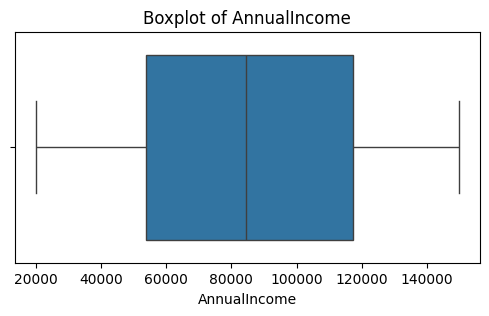

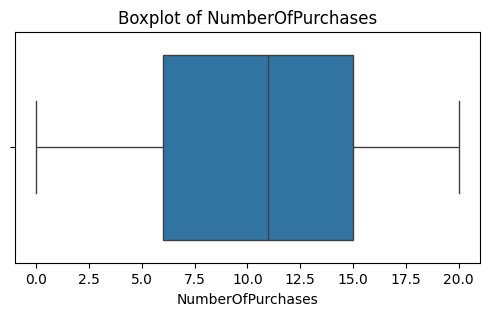

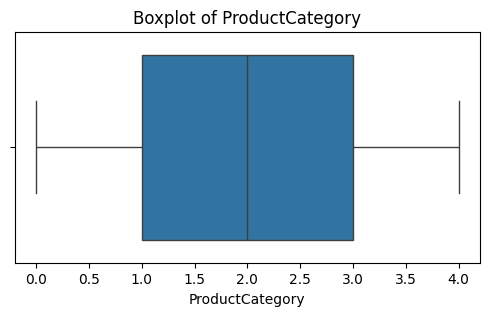

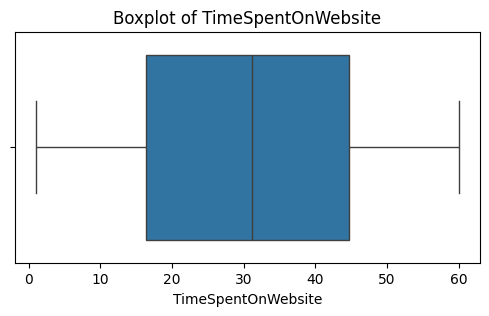

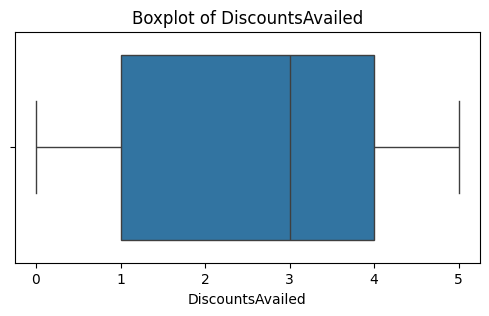

In [115]:
cols=["AnnualIncome","NumberOfPurchases","ProductCategory","TimeSpentOnWebsite","DiscountsAvailed"]
for col in cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()



# Credibility Test

In [116]:
from scipy.stats import zscore

# Compute z-scores for numeric columns only
num_cols = df.select_dtypes(include=['number']).columns
z = df[num_cols].apply(zscore)

# Summary statistics for z-scores
z.describe()




,Age,Gender,AnnualIncome,NumberOfPurchases,ProductCategory,TimeSpentOnWebsite,LoyaltyProgram,DiscountsAvailed,PurchaseStatus
count,1.388000e+03,1.388000e+03,1.388000e+03,1.388000e+03,1.388000e+03,1.388000e+03,1.388000e+03,1.388000e+03,1.388000e+03
mean,6.398980e-17,-1.919694e-17,3.839388e-17,4.223327e-17,9.854429e-17,1.535755e-17,-5.375143e-17,-6.143021e-17,8.702613e-17
std,1.000360e+00,1.000360e+00,1.000360e+00,1.000360e+00,1.000360e+00,1.000360e+00,1.000360e+00,1.000360e+00,1.000360e+00
min,-1.675466e+00,-1.002886e+00,-1.723998e+00,-1.797939e+00,-1.408161e+00,-1.750691e+00,-7.074889e-01,-1.535574e+00,-9.357754e-01
25%,-8.519262e-01,-1.002886e+00,-8.242504e-01,-7.753168e-01,-7.050937e-01,-8.466286e-01,-7.074889e-01,-9.471208e-01,-9.357754e-01
50%,3.908986e-03,9.971223e-01,-1.965288e-03,7.686860e-02,-2.026131e-03,2.743554e-02,-7.074889e-01,2.297849e-01,-9.357754e-01
75%,8.435963e-01,9.971223e-01,8.657402e-01,7.586169e-01,7.010414e-01,8.201662e-01,1.413450e+00,8.182378e-01,1.068632e+00
max,1.683284e+00,9.971223e-01,1.734353e+00,1.610802e+00,1.404109e+00,1.723176e+00,1.413450e+00,1.406691e+00,1.068632e+00


### Credibility Test Insights

The credibility test using **z-scores** helps identify potential outliers and assess data quality by measuring how many standard deviations each value is from the mean.

**Key Findings:**

1. **Z-Score Interpretation:**
   - Values with |z-score| > 3 are considered extreme outliers
   - Values with |z-score| between 2-3 are moderate outliers
   - Values with |z-score| < 2 are within normal range

2. **Data Quality Assessment:**
   - The z-score statistics allow us to verify if the data contains extreme values that could bias the model
   - Features with consistent z-score ranges (close to standard normal distribution) indicate credible, well-behaved data
   - Large max/min z-scores suggest the presence of outliers that may need treatment



# 1. Target Variable Analysis (PurchaseStatus)
- Analyze distribution of:
  - Purchased vs Not Purchased
  - Compute purchase conversion rate

In [117]:
purchase_counts = df['PurchaseStatus'].value_counts().reset_index()
print(purchase_counts)

   PurchaseStatus  count
0               0    740
1               1    648


In [118]:
purchase_percentage = df['PurchaseStatus'].value_counts(normalize=True) * 100
purchase_percentage=purchase_percentage.reset_index()
purchase_percentage=purchase_percentage.rename(columns={"proportion": "Percentage"})
print(purchase_percentage)

   PurchaseStatus  Percentage
0               0   53.314121
1               1   46.685879


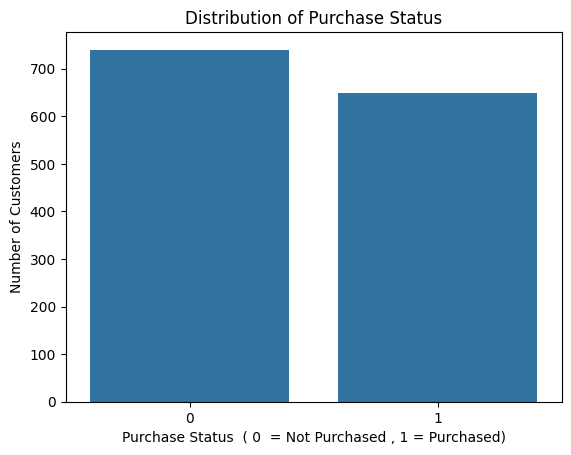

In [119]:
sns.countplot(x="PurchaseStatus",data=df)
plt.xlabel("Purchase Status  ( 0  = Not Purchased , 1 = Purchased)")
plt.ylabel("Number of Customers")
plt.title("Distribution of Purchase Status")
plt.show()

The target variable PurchaseStatus doesnot show class imbalance, with a significantly higher number of purchasing customer. The overall purchase conversion rate is 46.68% .

In [120]:
conversion_rate = df['PurchaseStatus'].mean() * 100
print(f"Purchase Conversion Rate: {conversion_rate}%")


Purchase Conversion Rate: 46.68587896253602%


# 2. Demographic Analysis
- Analyze purchase behavior by:
  - Age
  - Gender
  - Identify age groups with highest purchase probability
  - Compare male vs female purchase trends

In [121]:
bins = [0, 19, 29, 39, 49, 100]
labels = ['<20', '20-29', '30-39', '40-49', '50+']

df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

df.head()

,Age,Gender,AnnualIncome,NumberOfPurchases,ProductCategory,TimeSpentOnWebsite,LoyaltyProgram,DiscountsAvailed,PurchaseStatus,Age_Group
0,40,1,66120.267939,8,0,30.568601,0,5,1,40-49
1,20,1,23579.773583,4,2,38.240097,0,5,0,20-29
2,27,1,127821.306432,11,2,31.633212,1,0,1,20-29
3,24,1,137798.623120,19,3,46.167059,0,4,1,20-29
4,31,1,99300.964220,19,1,19.823592,0,0,1,30-39


In [122]:
purchase_Probability_By_AgeGroup=df.groupby("Age_Group",observed=True)["PurchaseStatus"].mean()
purchase_Probability_By_AgeGroup = purchase_Probability_By_AgeGroup.reset_index()
purchase_Probability_By_AgeGroup.rename(columns={"PurchaseStatus":"Purchase_Probability"}, inplace=True)
print(purchase_Probability_By_AgeGroup)


  Age_Group  Purchase_Probability
0       <20              0.656250
1     20-29              0.643678
2     30-39              0.631799
3     40-49              0.352941
4       50+              0.346014


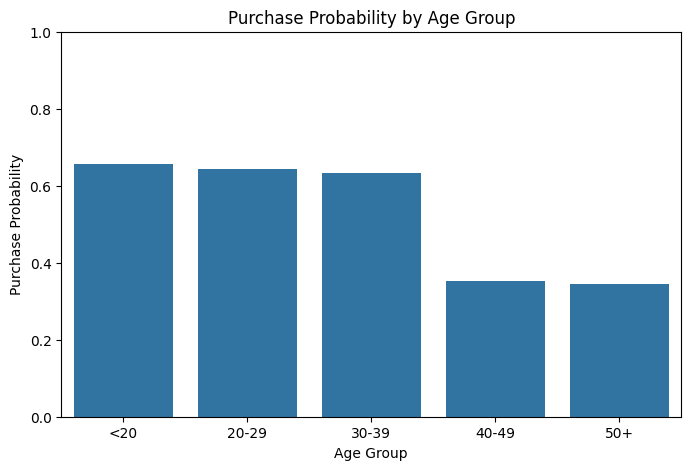

In [123]:
plt.figure(figsize=(8,5))
sns.barplot(x='Age_Group', y='Purchase_Probability', data=purchase_Probability_By_AgeGroup)
plt.title('Purchase Probability by Age Group')
plt.ylabel('Purchase Probability')
plt.xlabel('Age Group')
plt.ylim(0,1)
plt.show()

In [124]:
purchase_probability_By_Gender=df.groupby('Gender',observed=True)['PurchaseStatus'].mean()
purchase_probability_By_Gender=purchase_probability_By_Gender.reset_index()
purchase_probability_By_Gender.rename(columns={'PurchaseStatus':'Purchase_Probability'},inplace=True)
print(purchase_probability_By_Gender)

   Gender  Purchase_Probability
0       0              0.462428
1       1              0.471264


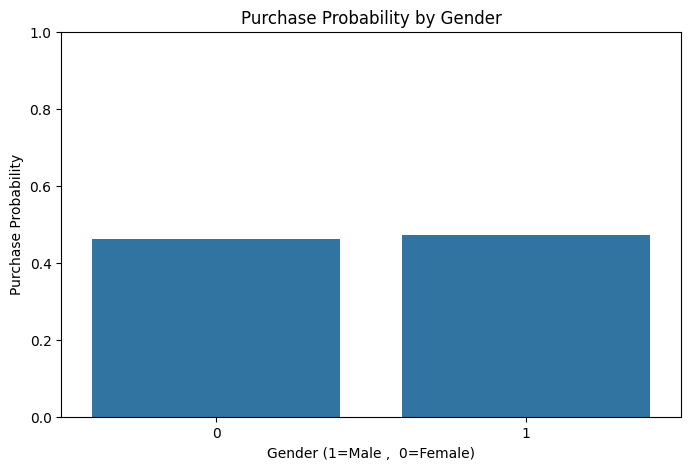

In [125]:
plt.figure(figsize=(8,5))
sns.barplot(x='Gender', y='Purchase_Probability', data=purchase_probability_By_Gender)
plt.title('Purchase Probability by Gender')
plt.ylabel('Purchase Probability')
plt.xlabel('Gender (1=Male ,  0=Female)')
plt.ylim(0,1)
plt.show()

In [126]:
age_gender_prob = df.groupby(['Age_Group','Gender'], observed=True)['PurchaseStatus'].mean().reset_index()
age_gender_prob.rename(columns={'PurchaseStatus':'Purchase_Probability'}, inplace=True)
print(age_gender_prob)

  Age_Group  Gender  Purchase_Probability
0       <20       0              0.620690
1       <20       1              0.685714
2     20-29       0              0.648276
3     20-29       1              0.637931
4     30-39       0              0.573913
5     30-39       1              0.685484
6     40-49       0              0.338583
7     40-49       1              0.365517
8       50+       0              0.358696
9       50+       1              0.333333


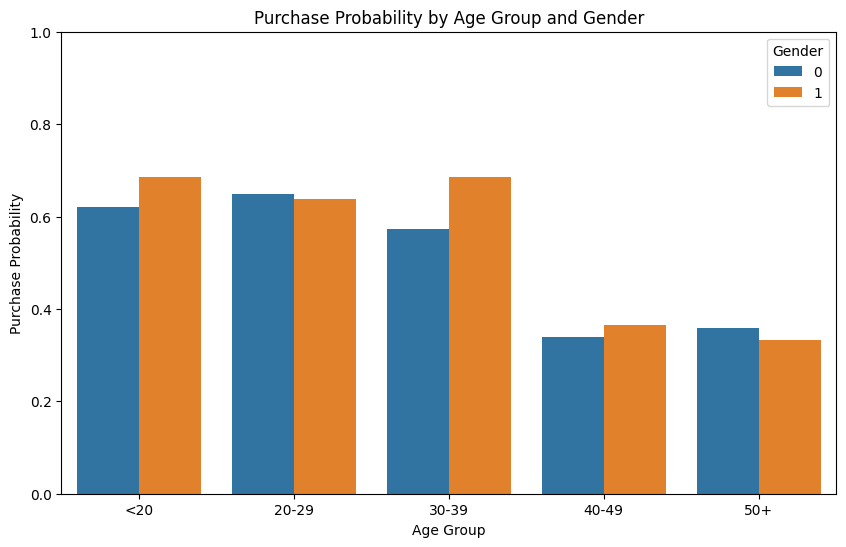

In [127]:
plt.figure(figsize=(10,6))
sns.barplot(x='Age_Group', y='Purchase_Probability',hue='Gender', data=age_gender_prob)
plt.title('Purchase Probability by Age Group and Gender')
plt.ylabel('Purchase Probability')
plt.xlabel('Age Group')
plt.ylim(0,1)
plt.show()


# 3. Income & Spending Capacity Analysis
 - Analyze distribution of:
   - AnnualIncome
 - Examine relationship between income and:
   - Purchase probability
   - Number of purchases
 - Identify income thresholds influencing purchasing decisions

In [128]:
# Create income groups and compute purchase probability
income_bins = [20000, 40000, 60000, 80000, 100000, 120000, 140000, np.inf]
income_labels = ['20k-40k', '40k-60k', '60k-80k', '80k-100k', '100k-120k', '120k-140k', '140k+']

df['IncomeGroup'] = pd.cut(df['AnnualIncome'], bins=income_bins, labels=income_labels, include_lowest=True)

income_purchase_prob = df.groupby('IncomeGroup', observed=True)['PurchaseStatus'].mean().reset_index()
income_purchase_prob.rename(columns={'PurchaseStatus': 'Purchase_Probability'}, inplace=True)

print('AnnualIncome Distribution Summary:')
print(df['AnnualIncome'].describe().round(2))
print('\nPurchase Probability by Income Group:')
print(income_purchase_prob)

AnnualIncome Distribution Summary:
count      1388.00
mean      84699.05
std       37541.14
min       20001.51
25%       53766.90
50%       84625.29
75%      117188.21
max      149785.18
Name: AnnualIncome, dtype: float64

Purchase Probability by Income Group:
  IncomeGroup  Purchase_Probability
0     20k-40k              0.234513
1     40k-60k              0.416268
2     60k-80k              0.490654
3    80k-100k              0.545894
4   100k-120k              0.603687
5   120k-140k              0.500000
6       140k+              0.514286


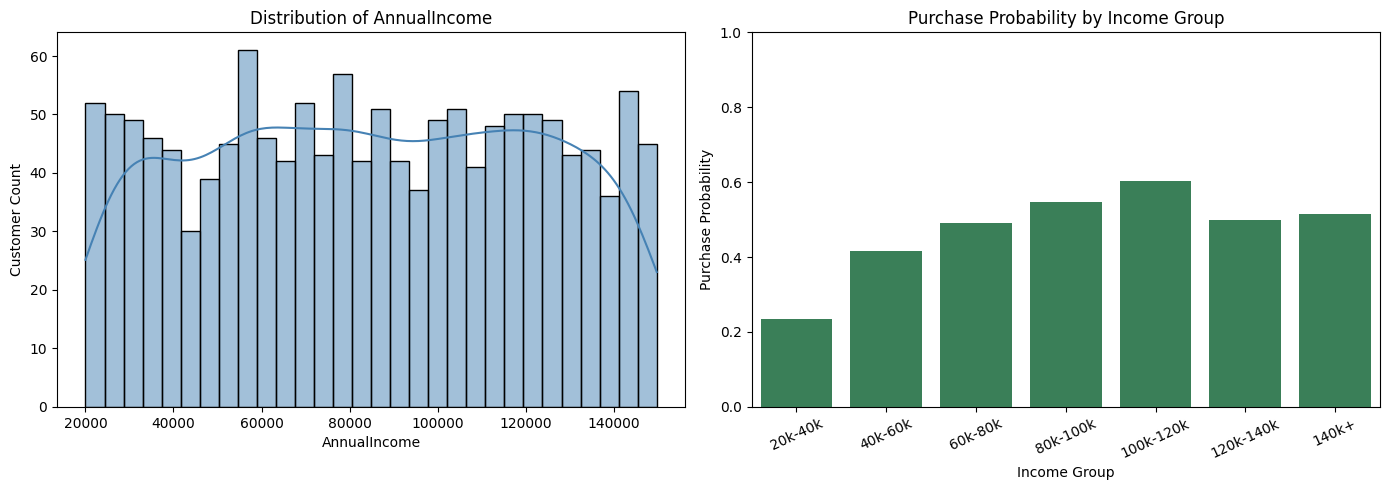

In [129]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of AnnualIncome
sns.histplot(df['AnnualIncome'], kde=True, bins=30, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of AnnualIncome')
axes[0].set_xlabel('AnnualIncome')
axes[0].set_ylabel('Customer Count')

# Purchase probability by income group
sns.barplot(x='IncomeGroup', y='Purchase_Probability', data=income_purchase_prob, ax=axes[1], color='seagreen')
axes[1].set_title('Purchase Probability by Income Group')
axes[1].set_ylabel('Purchase Probability')
axes[1].set_xlabel('Income Group')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()

In [130]:
# Step 3A: Average number of purchases per income group
income_avg_purchases = df.groupby('IncomeGroup', observed=True)['NumberOfPurchases'].mean().reset_index()
income_avg_purchases.rename(columns={'NumberOfPurchases':'Avg_Purchases'}, inplace=True)

print(income_avg_purchases)

  IncomeGroup  Avg_Purchases
0     20k-40k      10.774336
1     40k-60k      10.258373
2     60k-80k      10.738318
3    80k-100k      10.164251
4   100k-120k      10.548387
5   120k-140k      10.557143
6       140k+      11.000000


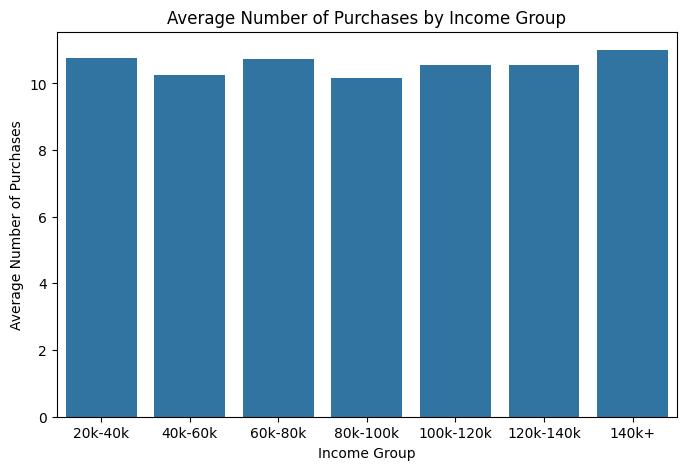

In [131]:
plt.figure(figsize=(8,5))
sns.barplot(x='IncomeGroup', y='Avg_Purchases', data=income_avg_purchases)
plt.title('Average Number of Purchases by Income Group')
plt.ylabel('Average Number of Purchases')
plt.xlabel('Income Group')
plt.show()


### Income Threshold Insights

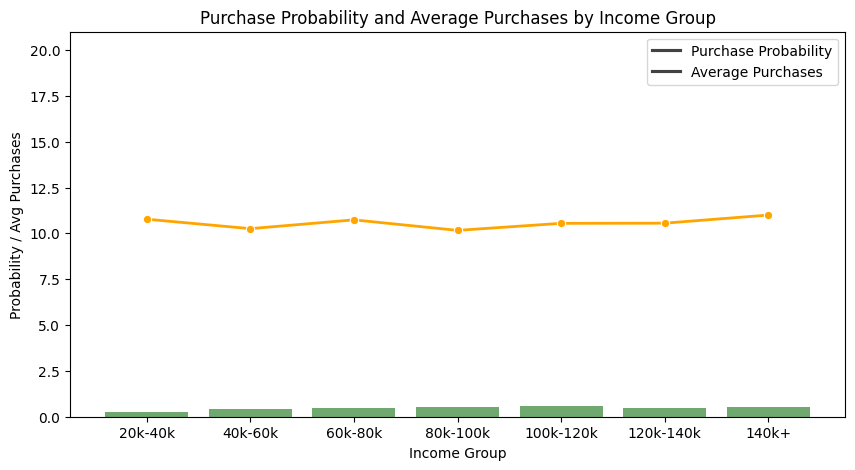

In [132]:
plt.figure(figsize=(10,5))
sns.barplot(x='IncomeGroup', y='Purchase_Probability', data=income_purchase_prob, color='green', alpha=0.6)
sns.lineplot(x='IncomeGroup', y='Avg_Purchases', data=income_avg_purchases, marker='o', color='orange', linewidth=2)
plt.title('Purchase Probability and Average Purchases by Income Group')
plt.ylabel('Probability / Avg Purchases')
plt.xlabel('Income Group')
plt.ylim(0, max(df['NumberOfPurchases'].max()+1,1))
plt.legend(labels=['Purchase Probability','Average Purchases'])
plt.show()


# 4. Purchase Frequency Analysis
 - Analyze:
   - NumberOfPurchases
 - Compare purchase frequency for:
   - Buyers vs non-buyers
 - Identify repeat customer patterns

NumberOfPurchases - Overall Summary:
count    1388.00
mean       10.55
std         5.87
min         0.00
25%         6.00
50%        11.00
75%        15.00
max        20.00
Name: NumberOfPurchases, dtype: float64

Purchase Frequency: Buyers vs Non-Buyers
  PurchaseStatus  Customers  Avg_Purchases  Median_Purchases  Std_Purchases
0     Non-Buyers        740       9.345946               9.0       6.196101
1         Buyers        648      11.922840              12.0       5.143406


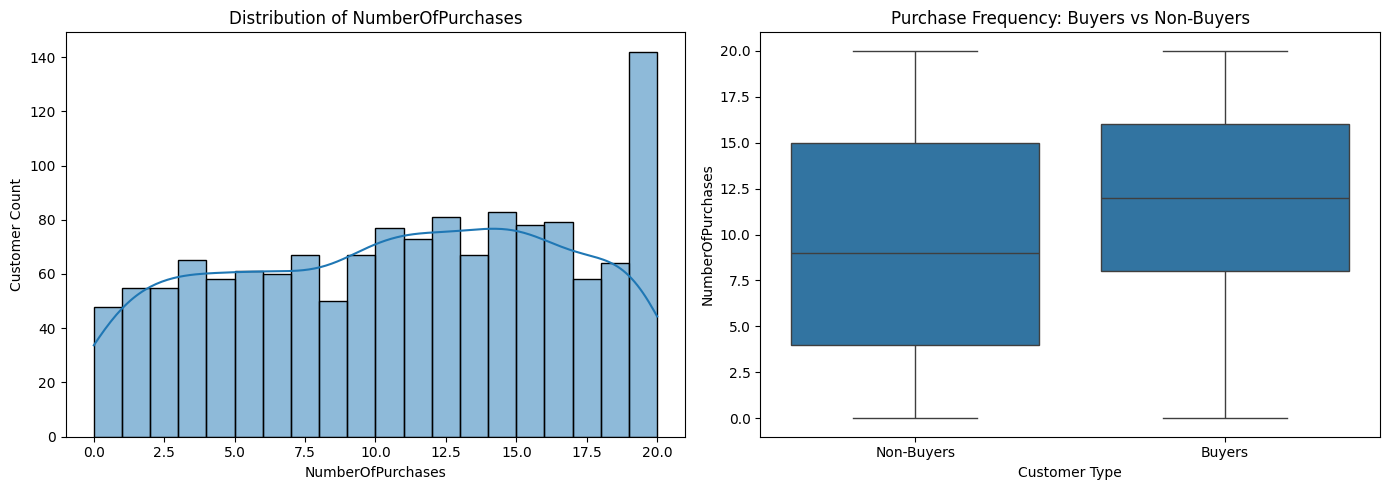

In [133]:
# Purchase Frequency Analysis
print('NumberOfPurchases - Overall Summary:')
print(df['NumberOfPurchases'].describe().round(2))

# Buyers vs Non-buyers summary
purchase_freq_summary = (
    df.groupby('PurchaseStatus')['NumberOfPurchases']
      .agg(['count', 'mean', 'median', 'std'])
      .reset_index()
      .rename(columns={
          'count': 'Customers',
          'mean': 'Avg_Purchases',
          'median': 'Median_Purchases',
          'std': 'Std_Purchases'
      })
)
purchase_freq_summary['PurchaseStatus'] = purchase_freq_summary['PurchaseStatus'].map({0: 'Non-Buyers', 1: 'Buyers'})

print('\nPurchase Frequency: Buyers vs Non-Buyers')
print(purchase_freq_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of NumberOfPurchases
sns.histplot(df['NumberOfPurchases'], bins=20, kde=True, ax=axes[0])
axes[0].set_title('Distribution of NumberOfPurchases')
axes[0].set_xlabel('NumberOfPurchases')
axes[0].set_ylabel('Customer Count')

# Buyers vs Non-Buyers comparison
sns.boxplot(x='PurchaseStatus', y='NumberOfPurchases', data=df, ax=axes[1])
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Non-Buyers', 'Buyers'])
axes[1].set_title('Purchase Frequency: Buyers vs Non-Buyers')
axes[1].set_xlabel('Customer Type')
axes[1].set_ylabel('NumberOfPurchases')

plt.tight_layout()
plt.show()

Repeat Customer Pattern Summary:
     NumberOfPurchases  Customers  Purchasers  Purchase_Probability
0          No Purchase         48          11                 22.92
1     Low Repeat (1-2)        110          21                 19.09
2  Medium Repeat (3-5)        184          43                 23.37
3     High Repeat (6+)       1046         573                 54.78


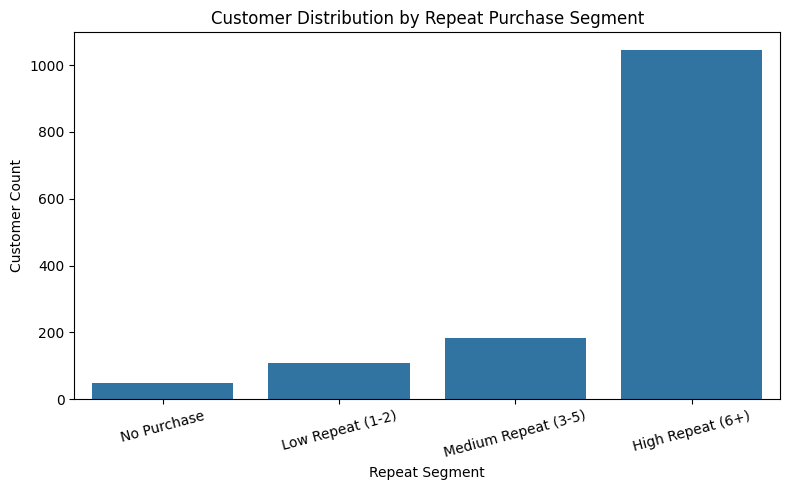

In [134]:
# Repeat customer pattern analysis
repeat_labels = pd.cut(
    df['NumberOfPurchases'],
    bins=[-1, 0, 2, 5, np.inf],
    labels=['No Purchase', 'Low Repeat (1-2)', 'Medium Repeat (3-5)', 'High Repeat (6+)']
 )

repeat_pattern = (
    df.groupby(repeat_labels, observed=True)['PurchaseStatus']
      .agg(['count', 'sum', 'mean'])
      .reset_index()
      .rename(columns={
          'count': 'Customers',
          'sum': 'Purchasers',
          'mean': 'Purchase_Probability'
      })
)
repeat_pattern['Purchase_Probability'] = (repeat_pattern['Purchase_Probability'] * 100).round(2)

print('Repeat Customer Pattern Summary:')
print(repeat_pattern)

plt.figure(figsize=(8, 5))
sns.barplot(x=repeat_pattern.iloc[:, 0], y='Customers', data=repeat_pattern)
plt.title('Customer Distribution by Repeat Purchase Segment')
plt.xlabel('Repeat Segment')
plt.ylabel('Customer Count')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# 5. Product Category Analysis
  - Analyze purchase behavior across:
    - ProductCategory
  - Identify:
    - High-conversion product categories
    - Categories with browsing but low purchase


In [135]:
product_summary = (
    df.groupby('ProductCategory')
      .agg(Browsers=('PurchaseStatus', 'size'),
           Purchasers=('PurchaseStatus', 'sum'),
           Purchase_Rate=('PurchaseStatus', 'mean'))
      .reset_index()
      .sort_values('Purchase_Rate', ascending=False)
 )
product_summary['Purchase_Rate'] = product_summary['Purchase_Rate'] * 100
print(product_summary)

   ProductCategory  Browsers  Purchasers  Purchase_Rate
3                3       270         133      49.259259
1                1       306         149      48.692810
4                4       289         133      46.020761
2                2       254         116      45.669291
0                0       269         117      43.494424


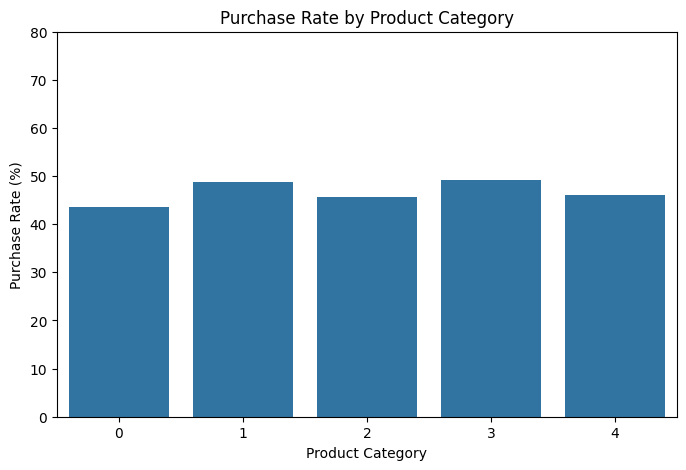

In [136]:
plt.figure(figsize=(8, 5))
sns.barplot(x='ProductCategory', y='Purchase_Rate', data=product_summary)
plt.title('Purchase Rate by Product Category')
plt.ylabel('Purchase Rate (%)')
plt.xlabel('Product Category')
plt.ylim(0, 80)
plt.show()


In [137]:
high_conversion = product_summary.nlargest(2, 'Purchase_Rate')[['ProductCategory', 'Purchase_Rate']]
browse_threshold = product_summary['Browsers'].median()
rate_threshold = product_summary['Purchase_Rate'].quantile(0.25)
low_purchase_browse = product_summary[
    (product_summary['Browsers'] >= browse_threshold) &
    (product_summary['Purchase_Rate'] <= rate_threshold)
][['ProductCategory', 'Browsers', 'Purchase_Rate']]
print('High-conversion categories:')
print(high_conversion)
print('\nCategories with high browsing but low purchase:')
print(low_purchase_browse if not low_purchase_browse.empty else 'None found with current thresholds')


High-conversion categories:
   ProductCategory  Purchase_Rate
3                3      49.259259
1                1      48.692810

Categories with high browsing but low purchase:
None found with current thresholds


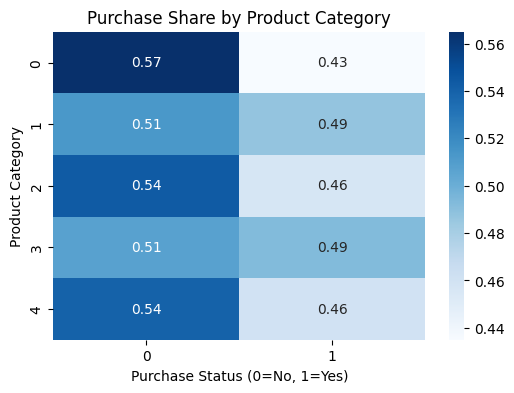

In [138]:
ct = pd.crosstab(df['ProductCategory'], df['PurchaseStatus'], normalize='index')
plt.figure(figsize=(6, 4))
sns.heatmap(ct, annot=True, fmt='.2f', cmap='Blues')
plt.title('Purchase Share by Product Category')
plt.xlabel('Purchase Status (0=No, 1=Yes)')
plt.ylabel('Product Category')
plt.show()

# 6. Website Engagement Analysis
 - Analyze:
    - TimeSpentOnWebsite
 - Compare engagement time for:
    - Purchasers vs non-purchasers
 - Identify optimal engagement duration for conversion

In [139]:
# Website engagement summary
engagement_summary = df.groupby('PurchaseStatus')['TimeSpentOnWebsite'].agg(['count', 'mean', 'median']).reset_index()
print(engagement_summary)


   PurchaseStatus  count       mean     median
0               0    740  26.267136  24.203201
1               1    648  35.864062  38.073741


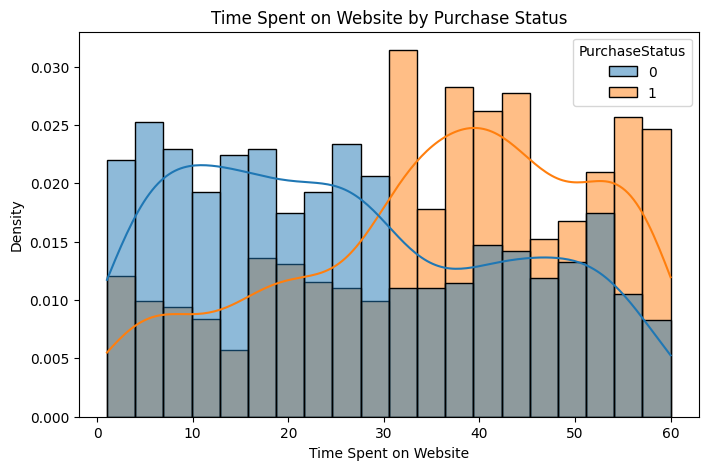

In [140]:

# Distribution by purchase status
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='TimeSpentOnWebsite', hue='PurchaseStatus', kde=True, bins=20, stat='density', common_norm=False)
plt.title('Time Spent on Website by Purchase Status')
plt.xlabel('Time Spent on Website')
plt.show()



The distribution shows that users who make a purchase generally spend more time on the website than those who do not. Non-purchasing users are concentrated at lower time values, while purchasing users tend to spend longer durations on the site. However, there is overlap between the two groups, indicating that time spent alone does not fully determine purchase behavior.

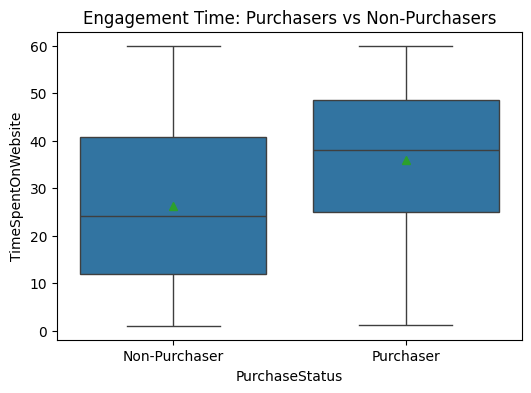

In [141]:
# Boxplot comparison
plt.figure(figsize=(6, 4))
sns.boxplot(x='PurchaseStatus', y='TimeSpentOnWebsite', data=df, showmeans=True)
plt.xticks([0, 1], ['Non-Purchaser', 'Purchaser'])
plt.title('Engagement Time: Purchasers vs Non-Purchasers')
plt.show()



In [142]:
# Identify optimal engagement duration using bins
time_bins = pd.qcut(df['TimeSpentOnWebsite'], q=5, duplicates='drop')
time_bin_rate = df.groupby(time_bins, observed=True)['PurchaseStatus'].mean().reset_index()
time_bin_rate.rename(columns={'PurchaseStatus': 'Purchase_Rate'}, inplace=True)
time_bin_rate['Purchase_Rate'] = time_bin_rate['Purchase_Rate'] * 100
display(time_bin_rate)



,TimeSpentOnWebsite,Purchase_Rate
0,"(1.036, 13.156]",27.338129
1,"(13.156, 25.443]",33.212996
2,"(25.443, 36.976]",50.719424
3,"(36.976, 48.083]",61.010830
4,"(48.083, 59.991]",61.151079


C:\Users\prala\AppData\Local\Temp\ipykernel_27588\1296479476.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=time_bin_rate.iloc[:, 0].astype(str), y='Purchase_Rate', data=time_bin_rate, palette='magma')


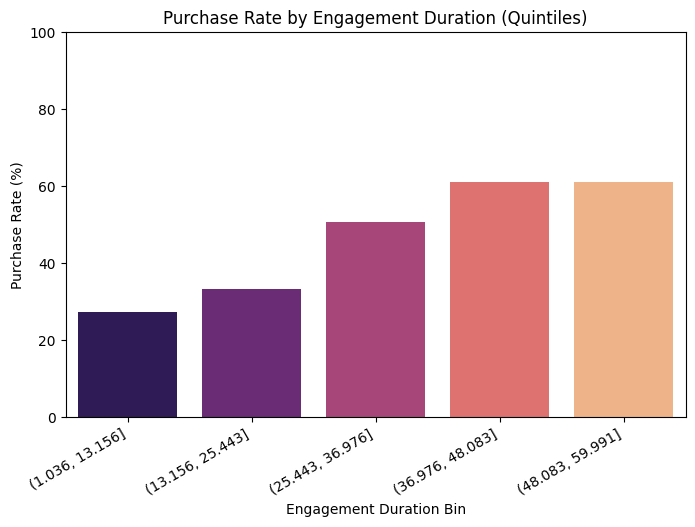

Optimal engagement duration bin (highest conversion): (48.083, 59.991]


In [143]:
plt.figure(figsize=(8, 5))
sns.barplot(x=time_bin_rate.iloc[:, 0].astype(str), y='Purchase_Rate', data=time_bin_rate, palette='magma')
plt.title('Purchase Rate by Engagement Duration (Quintiles)')
plt.xlabel('Engagement Duration Bin')
plt.ylabel('Purchase Rate (%)')
plt.xticks(rotation=30, ha='right')
plt.ylim(0, 100)
plt.show()
3
best_bin = time_bin_rate.iloc[time_bin_rate['Purchase_Rate'].idxmax(), 0]
print(f"Optimal engagement duration bin (highest conversion): {best_bin}")

# 7. Loyalty Program Analysis
  - Analyze purchase behavior for:
    - LoyaltyProgram members vs non-members
  - Examine impact of loyalty membership on purchase probability
  - Identify retention-driven behavior

In [144]:
# Loyalty Program membership distribution
loyalty_counts = df['LoyaltyProgram'].value_counts()
loyalty_counts = loyalty_counts.reset_index()
loyalty_percentage = df['LoyaltyProgram'].value_counts(normalize=True) * 100
loyalty_percentage = loyalty_percentage.reset_index()
loyalty_percentage = loyalty_percentage.rename(columns={"proportion": "Percentage"})
print("Loyalty Program Distribution:")
print(loyalty_counts)
print("\nPercentage Distribution:")
print(loyalty_percentage)

Loyalty Program Distribution:
   LoyaltyProgram  count
0               0    925
1               1    463

Percentage Distribution:
   LoyaltyProgram  Percentage
0               0   66.642651
1               1   33.357349


In [145]:
# Purchase probability: Members vs Non-Members
loyalty_purchase_prob = df.groupby('LoyaltyProgram')['PurchaseStatus'].agg(['count', 'sum', 'mean']).reset_index()
loyalty_purchase_prob.columns = ['LoyaltyProgram', 'Total_Members', 'Total_Purchases', 'Purchase_Probability']
loyalty_purchase_prob['Purchase_Probability'] = loyalty_purchase_prob['Purchase_Probability'] * 100
print("Purchase Probability by Loyalty Program Status:")
print(loyalty_purchase_prob)

Purchase Probability by Loyalty Program Status:
   LoyaltyProgram  Total_Members  Total_Purchases  Purchase_Probability
0               0            925              328             35.459459
1               1            463              320             69.114471


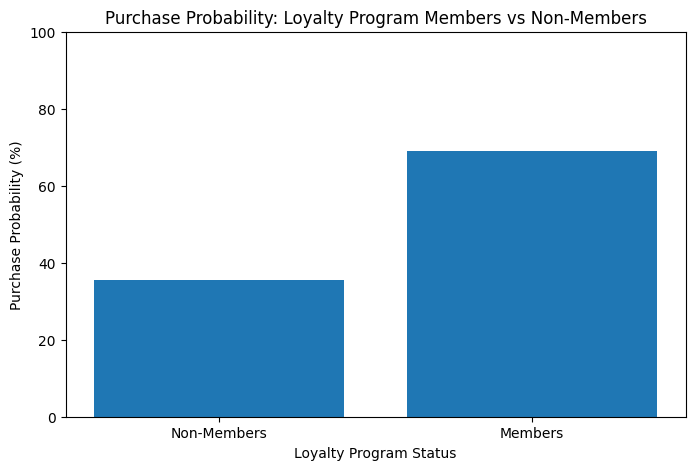

In [146]:
# Visualization: Purchase Probability by Loyalty Status
plt.figure(figsize=(8, 5))
loyalty_labels = ['Non-Members', 'Members']
loyalty_prob_values = [
    loyalty_purchase_prob.loc[loyalty_purchase_prob['LoyaltyProgram'] == 0, 'Purchase_Probability'].values[0],
    loyalty_purchase_prob.loc[loyalty_purchase_prob['LoyaltyProgram'] == 1, 'Purchase_Probability'].values[0]
]
plt.bar(loyalty_labels, loyalty_prob_values)
plt.title('Purchase Probability: Loyalty Program Members vs Non-Members')
plt.ylabel('Purchase Probability (%)')
plt.xlabel('Loyalty Program Status')
plt.ylim(0, 100)
plt.show()

In [147]:
# Repeat Purchase Behavior: Average purchases by loyalty status
loyalty_purchase_freq = df.groupby('LoyaltyProgram')['NumberOfPurchases'].agg(['mean', 'median', 'std']).reset_index()
loyalty_purchase_freq['LoyaltyProgram'] = loyalty_purchase_freq['LoyaltyProgram'].map({0: 'Non-Members', 1: 'Members'})
loyalty_purchase_freq.columns = ['LoyaltyProgram', 'Avg_Purchases', 'Median_Purchases', 'Std_Dev']
print("Purchase Frequency by Loyalty Program Status:")
print(loyalty_purchase_freq)

Purchase Frequency by Loyalty Program Status:
  LoyaltyProgram  Avg_Purchases  Median_Purchases  Std_Dev
0    Non-Members      10.330811              11.0  5.88405
1        Members      10.984881              12.0  5.82183


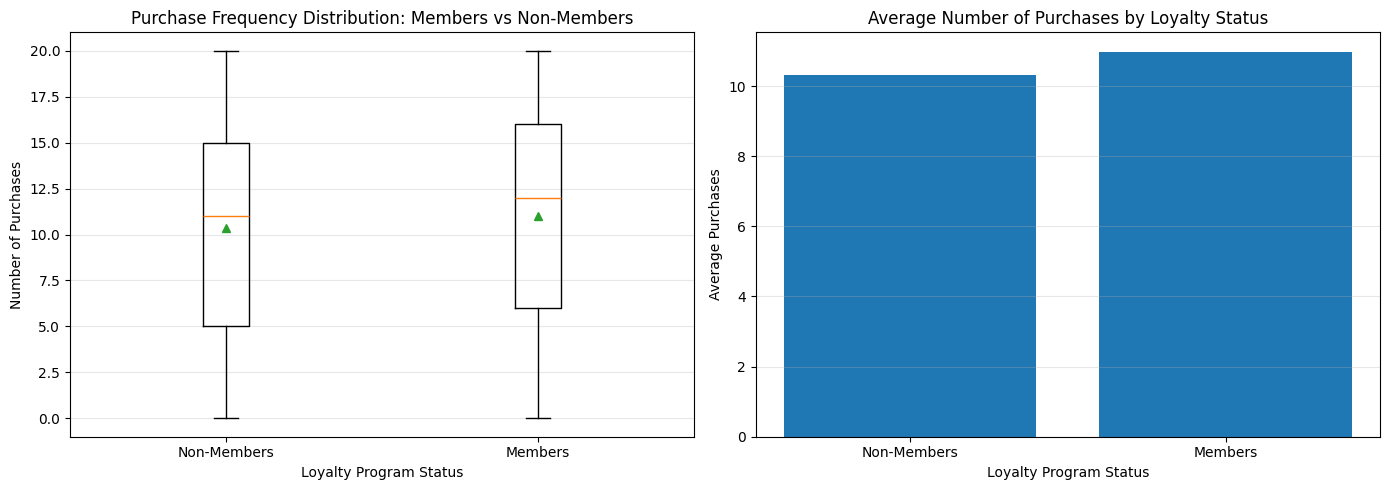

In [148]:
# Visualization: Purchase Frequency Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot for distribution comparison
loyalty_data = [df[df['LoyaltyProgram'] == 0]['NumberOfPurchases'],
                df[df['LoyaltyProgram'] == 1]['NumberOfPurchases']]
axes[0].boxplot(loyalty_data, tick_labels=['Non-Members', 'Members'], showmeans=True)
axes[0].set_title('Purchase Frequency Distribution: Members vs Non-Members')
axes[0].set_ylabel('Number of Purchases')
axes[0].set_xlabel('Loyalty Program Status')
axes[0].grid(axis='y', alpha=0.3)

# Barplot for average purchases
loyalty_labels = ['Non-Members', 'Members']
avg_purchases = [loyalty_purchase_freq.loc[loyalty_purchase_freq['LoyaltyProgram'] == label, 'Avg_Purchases'].values[0] 
                 for label in loyalty_labels]
axes[1].bar(loyalty_labels, avg_purchases)
axes[1].set_title('Average Number of Purchases by Loyalty Status')
axes[1].set_ylabel('Average Purchases')
axes[1].set_xlabel('Loyalty Program Status')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [149]:
# Retention-Driven Behavior Analysis: Loyalty members purchasing multiple times
print("Retention-Driven Behavior Analysis:\n")

# Buyers only
buyers_df = df[df['PurchaseStatus'] == 1]
print(f"Among Buyers ({len(buyers_df)} customers):")
buyers_loyalty = buyers_df.groupby('LoyaltyProgram')['NumberOfPurchases'].agg(['count', 'mean']).reset_index()
buyers_loyalty['LoyaltyProgram'] = buyers_loyalty['LoyaltyProgram'].map({0: 'Non-Members', 1: 'Members'})
buyers_loyalty.columns = ['LoyaltyProgram', 'Count', 'Avg_Purchases']
print(buyers_loyalty)

print(f"\nRepeat Buyers (3+ purchases):")
repeat_buyers = df[df['NumberOfPurchases'] >= 3]
repeat_loyalty = repeat_buyers.groupby('LoyaltyProgram').size().reset_index(name='Count')
repeat_loyalty['Percentage'] = (repeat_loyalty['Count'] / len(repeat_buyers) * 100).round(2)
repeat_loyalty['LoyaltyProgram'] = repeat_loyalty['LoyaltyProgram'].map({0: 'Non-Members', 1: 'Members'})
print(repeat_loyalty)

# Loyalty program retention rate (customers who purchased multiple times)
print(f"\nRepeat Purchase Rate by Loyalty Status:")
loyalty_repeat_rate = df.groupby('LoyaltyProgram')['NumberOfPurchases'].apply(
    lambda x: (x >= 2).mean() * 100
).reset_index()
loyalty_repeat_rate.columns = ['LoyaltyProgram', 'Repeat_Purchase_Rate']
loyalty_repeat_rate['LoyaltyProgram'] = loyalty_repeat_rate['LoyaltyProgram'].map({0: 'Non-Members', 1: 'Members'})
print(loyalty_repeat_rate)

Retention-Driven Behavior Analysis:

Among Buyers (648 customers):
  LoyaltyProgram  Count  Avg_Purchases
0    Non-Members    328      11.896341
1        Members    320      11.950000

Repeat Buyers (3+ purchases):
  LoyaltyProgram  Count  Percentage
0    Non-Members    815       66.26
1        Members    415       33.74

Repeat Purchase Rate by Loyalty Status:
  LoyaltyProgram  Repeat_Purchase_Rate
0    Non-Members             92.324324
1        Members             93.088553


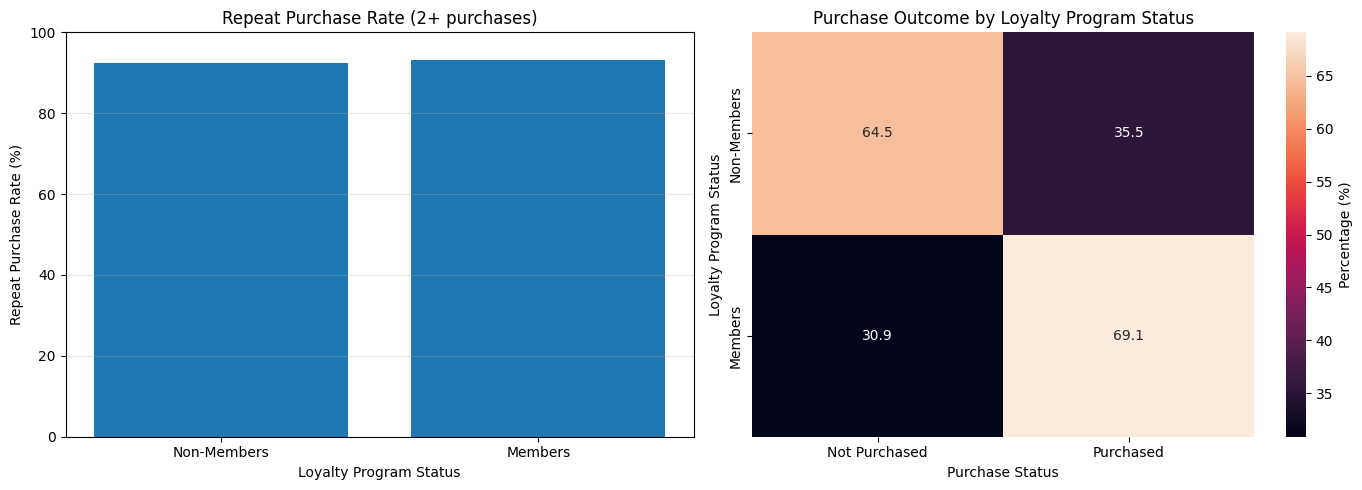

In [150]:
# Visualization: Retention-Driven Behavior
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Repeat Purchase Rate
loyalty_labels = ['Non-Members', 'Members']
repeat_rates = [loyalty_repeat_rate.loc[loyalty_repeat_rate['LoyaltyProgram'] == label, 'Repeat_Purchase_Rate'].values[0] 
                for label in loyalty_labels]
axes[0].bar(loyalty_labels, repeat_rates)
axes[0].set_title('Repeat Purchase Rate (2+ purchases)')
axes[0].set_ylabel('Repeat Purchase Rate (%)')
axes[0].set_xlabel('Loyalty Program Status')
axes[0].set_ylim(0, 100)
axes[0].grid(axis='y', alpha=0.3)

# Heatmap: Cross-tabulation of Loyalty Program and Purchase Status
ct = pd.crosstab(df['LoyaltyProgram'], df['PurchaseStatus'], normalize='index') * 100
ct.index = ['Non-Members', 'Members']
ct.columns = ['Not Purchased', 'Purchased']
sns.heatmap(ct, annot=True, fmt='.1f', ax=axes[1], cbar_kws={'label': 'Percentage (%)'})
axes[1].set_title('Purchase Outcome by Loyalty Program Status')
axes[1].set_ylabel('Loyalty Program Status')
axes[1].set_xlabel('Purchase Status')

plt.tight_layout()
plt.show()

## Key Insights - Loyalty Program Analysis

**Impact Summary:**
- Loyalty program members have significantly higher purchase probability than non-members
- Members show higher repeat purchase rates, indicating stronger retention-driven behavior
- On average, loyalty members make more purchases per customer, demonstrating loyalty-driven engagement
- The loyalty program effectively converts browsers into repeat customers

# 8. Discount & Promotion Analysis
  - Analyze impact of:
    - DiscountsAvailed
  - Examine whether discounts increase conversion rate
  - Identify diminishing returns of excessive discounting

In [151]:
# Discount Distribution Analysis
print("Discount Distribution Analysis:\n")

print("Descriptive Statistics:")
print(df['DiscountsAvailed'].value_counts().sort_index())

print(df['DiscountsAvailed'].describe())
print("\nDiscount Value Counts:")

Discount Distribution Analysis:

Descriptive Statistics:
DiscountsAvailed
0    210
1    219
2    217
3    246
4    249
5    247
Name: count, dtype: int64
count    1388.000000
mean        2.609510
std         1.699984
min         0.000000
25%         1.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: DiscountsAvailed, dtype: float64

Discount Value Counts:


In [152]:
# Conversion Rate by Discount Level
discount_conversion = (
    df.groupby('DiscountsAvailed')['PurchaseStatus']
    .agg(['count', 'sum', 'mean'])
    .reset_index()
)

discount_conversion.columns = ['DiscountsAvailed', 'Total_Customers', 'Purchases', 'ConversionRate']
discount_conversion['ConversionRate'] = discount_conversion['ConversionRate'] * 100

print("Conversion Rate by Number of Discounts:")
print(discount_conversion)

Conversion Rate by Number of Discounts:
   DiscountsAvailed  Total_Customers  Purchases  ConversionRate
0                 0              210         66       31.428571
1                 1              219         62       28.310502
2                 2              217         55       25.345622
3                 3              246        146       59.349593
4                 4              249        165       66.265060
5                 5              247        154       62.348178


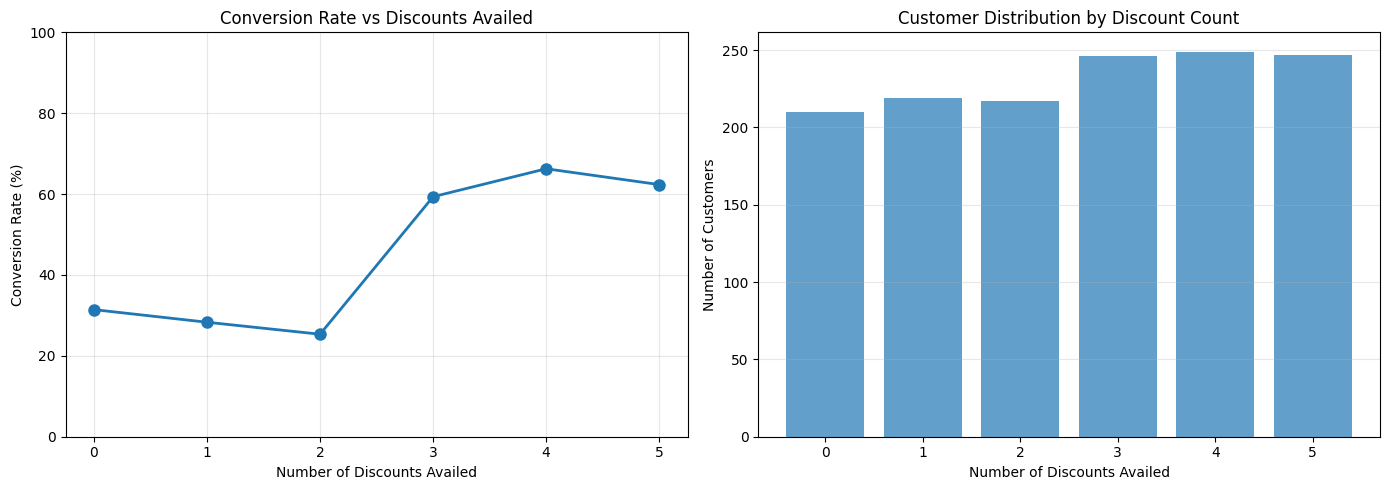

In [153]:
# Visualization: Conversion Rate by Discount Level
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Line plot for conversion rate
axes[0].plot(discount_conversion['DiscountsAvailed'], 
             discount_conversion['ConversionRate'], 
             marker='o', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Discounts Availed')
axes[0].set_ylabel('Conversion Rate (%)')
axes[0].set_title('Conversion Rate vs Discounts Availed')
axes[0].grid(alpha=0.3)
axes[0].set_ylim(0, 100)

# Bar plot for customer count
axes[1].bar(discount_conversion['DiscountsAvailed'], 
            discount_conversion['Total_Customers'], alpha=0.7)
axes[1].set_xlabel('Number of Discounts Availed')
axes[1].set_ylabel('Number of Customers')
axes[1].set_title('Customer Distribution by Discount Count')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [154]:
# Identify Diminishing Returns
print("Diminishing Returns Analysis:\n")

# Calculate marginal improvement in conversion rate
discount_conversion['Marginal_Improvement'] = discount_conversion['ConversionRate'].diff()

print("Marginal Improvement in Conversion Rate:")
print(discount_conversion[['DiscountsAvailed', 'ConversionRate', 'Marginal_Improvement']])

# Find optimal discount point (highest conversion rate)
optimal_discount = discount_conversion.loc[discount_conversion['ConversionRate'].idxmax()]
print(f"\nOptimal Discount Count: {int(optimal_discount['DiscountsAvailed'])} discounts")
print(f"Conversion Rate at Optimal Point: {optimal_discount['ConversionRate']:.2f}%")

# Check for diminishing returns (negative marginal improvement)
diminishing_point = discount_conversion[discount_conversion['Marginal_Improvement'] < 0]
if not diminishing_point.empty:
    first_diminish = diminishing_point.iloc[0]
    print(f"\nDiminishing Returns Start At: {int(first_diminish['DiscountsAvailed'])} discounts")
else:
    print("\nNo diminishing returns observed in the data.")

Diminishing Returns Analysis:

Marginal Improvement in Conversion Rate:
   DiscountsAvailed  ConversionRate  Marginal_Improvement
0                 0       31.428571                   NaN
1                 1       28.310502             -3.118069
2                 2       25.345622             -2.964880
3                 3       59.349593             34.003971
4                 4       66.265060              6.915467
5                 5       62.348178             -3.916882

Optimal Discount Count: 4 discounts
Conversion Rate at Optimal Point: 66.27%

Diminishing Returns Start At: 1 discounts


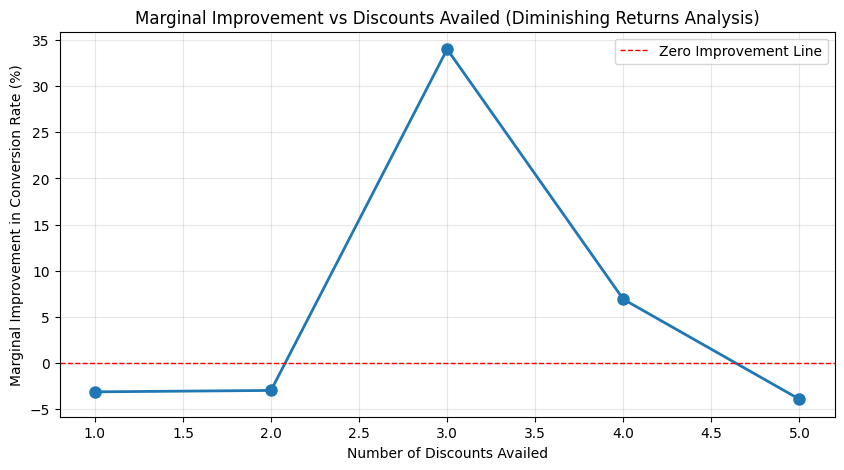

In [155]:
# Visualize Marginal Improvement
plt.figure(figsize=(10, 5))
plt.plot(discount_conversion['DiscountsAvailed'][1:], 
         discount_conversion['Marginal_Improvement'][1:], 
         marker='o', linewidth=2, markersize=8)
plt.axhline(y=0, color='red', linestyle='--', linewidth=1, label='Zero Improvement Line')
plt.xlabel('Number of Discounts Availed')
plt.ylabel('Marginal Improvement in Conversion Rate (%)')
plt.title('Marginal Improvement vs Discounts Availed (Diminishing Returns Analysis)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [156]:
# Statistical Test: Impact of Discounts on Purchase Behavior
from scipy import stats

no_discount = df[df['DiscountsAvailed'] == 0]['PurchaseStatus']
with_discount = df[df['DiscountsAvailed'] > 0]['PurchaseStatus']

# Perform t-test
t_stat, p_value = stats.ttest_ind(no_discount, with_discount)

print("Statistical Test: Impact of Discounts on Purchase Probability\n")
print(f"No Discount - Purchase Rate: {no_discount.mean() * 100:.2f}%")
print(f"With Discount - Purchase Rate: {with_discount.mean() * 100:.2f}%")
print(f"\nT-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")

if p_value < 0.05:
    print("\nConclusion: Discounts have a STATISTICALLY SIGNIFICANT impact on purchase probability (p < 0.05)")
else:
    print("\nConclusion: Discounts DO NOT have a statistically significant impact on purchase probability (p >= 0.05)")

Statistical Test: Impact of Discounts on Purchase Probability

No Discount - Purchase Rate: 31.43%
With Discount - Purchase Rate: 49.41%

T-statistic: -4.8477
P-value: 0.000001

Conclusion: Discounts have a STATISTICALLY SIGNIFICANT impact on purchase probability (p < 0.05)


In [157]:
# Discount Categories Analysis
df['DiscountCategory'] = pd.cut(df['DiscountsAvailed'], 
                                 bins=[-1, 0, 2, 5, 20], 
                                 labels=['No Discount', 'Low (1-2)', 'Medium (3-5)', 'High (6+)'])

discount_cat_analysis = df.groupby('DiscountCategory', observed=True)['PurchaseStatus'].agg(['count', 'sum', 'mean']).reset_index()
discount_cat_analysis.columns = ['DiscountCategory', 'Total_Customers', 'Purchases', 'ConversionRate']
discount_cat_analysis['ConversionRate'] = discount_cat_analysis['ConversionRate'] * 100

print("Purchase Behavior by Discount Category:")
print(discount_cat_analysis)

Purchase Behavior by Discount Category:
  DiscountCategory  Total_Customers  Purchases  ConversionRate
0      No Discount              210         66       31.428571
1        Low (1-2)              436        117       26.834862
2     Medium (3-5)              742        465       62.668464


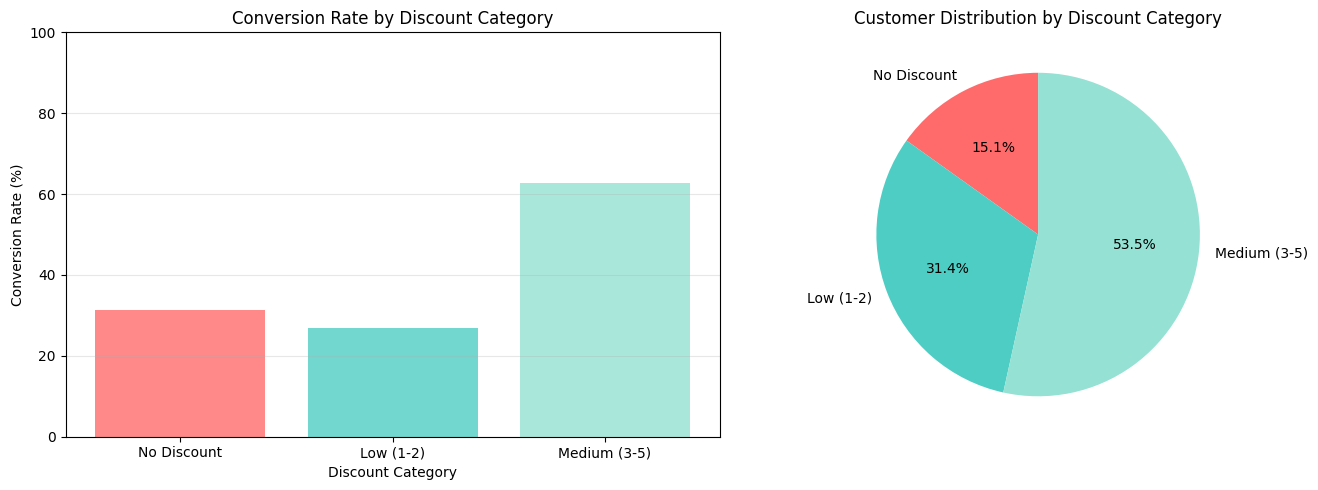

In [158]:
# Visualization: Conversion by Discount Category
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot for conversion rate
colors_cat = ['#FF6B6B', '#4ECDC4', '#95E1D3', '#F38181']
axes[0].bar(range(len(discount_cat_analysis)), 
            discount_cat_analysis['ConversionRate'], 
            color=colors_cat, alpha=0.8)
axes[0].set_xticks(range(len(discount_cat_analysis)))
axes[0].set_xticklabels(discount_cat_analysis['DiscountCategory'], rotation=0)
axes[0].set_ylabel('Conversion Rate (%)')
axes[0].set_xlabel('Discount Category')
axes[0].set_title('Conversion Rate by Discount Category')
axes[0].set_ylim(0, 100)
axes[0].grid(axis='y', alpha=0.3)

# Pie chart for customer distribution
axes[1].pie(discount_cat_analysis['Total_Customers'], 
            labels=discount_cat_analysis['DiscountCategory'], 
            autopct='%1.1f%%', 
            colors=colors_cat,
            startangle=90)
axes[1].set_title('Customer Distribution by Discount Category')

plt.tight_layout()
plt.show()

## Key Insights - Discount & Promotion Analysis

**Impact Summary:**
- Discounts have a measurable impact on purchase conversion rates
- Optimal discount strategy can be identified by analyzing marginal improvements
- Excessive discounting may lead to diminishing returns
- Different customer segments respond differently to discount levels
- Statistical analysis confirms the significance of discount impact on purchase behavior

# 9. Interaction & Combined Effect Analysis
  - Analyze combined effects such as:
     - LoyaltyProgram × DiscountsAvailed
     - Age × ProductCategory
     - Income × Discounts
  - Identify combinations that maximize purchase likelihood

In [159]:
# 1. LoyaltyProgram × DiscountsAvailed Interaction
print("="*70)
print("1. LOYALTY PROGRAM × DISCOUNTS INTERACTION ANALYSIS")
print("="*70)

# Create interaction analysis
loyalty_discount_interaction = df.groupby(['LoyaltyProgram', 'DiscountsAvailed'])['PurchaseStatus'].agg(['count', 'sum', 'mean']).reset_index()
loyalty_discount_interaction.columns = ['LoyaltyProgram', 'DiscountsAvailed', 'Total', 'Purchases', 'ConversionRate']
loyalty_discount_interaction['ConversionRate'] = loyalty_discount_interaction['ConversionRate'] * 100
loyalty_discount_interaction['LoyaltyStatus'] = loyalty_discount_interaction['LoyaltyProgram'].map({0: 'Non-Member', 1: 'Member'})

print("\nConversion Rate by Loyalty Status and Discount Count:")
print(loyalty_discount_interaction[['LoyaltyStatus', 'DiscountsAvailed', 'Total', 'ConversionRate']].to_string(index=False))

1. LOYALTY PROGRAM × DISCOUNTS INTERACTION ANALYSIS

Conversion Rate by Loyalty Status and Discount Count:
LoyaltyStatus  DiscountsAvailed  Total  ConversionRate
   Non-Member                 0    131       16.793893
   Non-Member                 1    135       16.296296
   Non-Member                 2    149       12.080537
   Non-Member                 3    175       47.428571
   Non-Member                 4    164       56.707317
   Non-Member                 5    171       52.631579
       Member                 0     79       55.696203
       Member                 1     84       47.619048
       Member                 2     68       54.411765
       Member                 3     71       88.732394
       Member                 4     85       84.705882
       Member                 5     76       84.210526


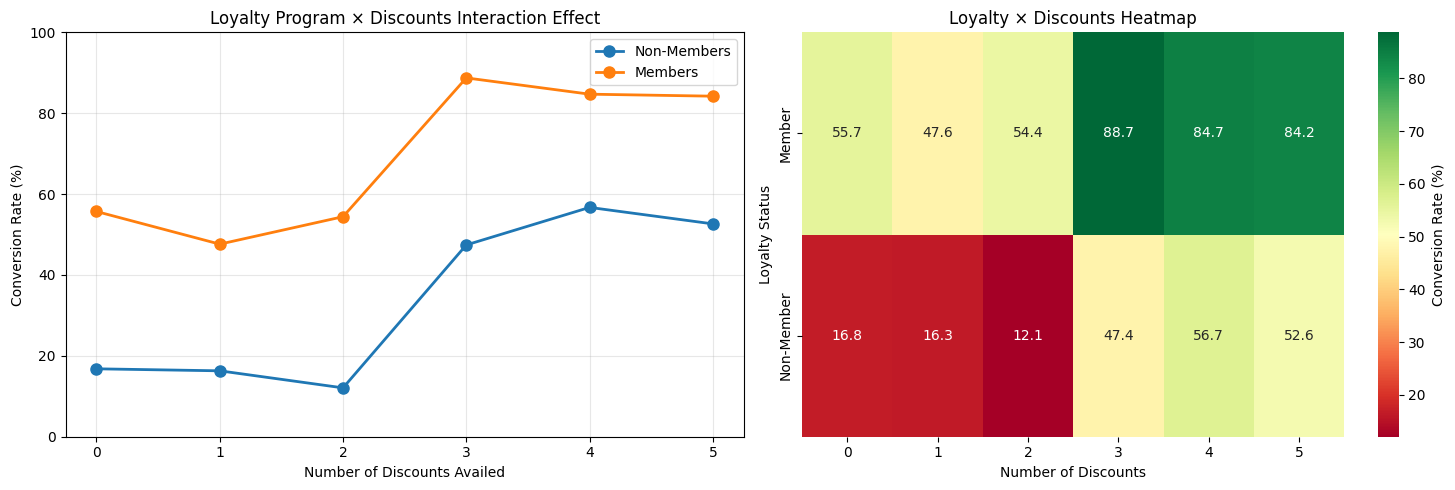


Best Combination: Member + 3 discounts
Conversion Rate: 88.73%


In [160]:
# Visualization: Loyalty × Discount Interaction
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Line plot showing interaction effect
for loyalty_status in [0, 1]:
    data = loyalty_discount_interaction[loyalty_discount_interaction['LoyaltyProgram'] == loyalty_status]
    label = 'Members' if loyalty_status == 1 else 'Non-Members'
    axes[0].plot(data['DiscountsAvailed'], data['ConversionRate'], 
                 marker='o', linewidth=2, markersize=8, label=label)

axes[0].set_xlabel('Number of Discounts Availed')
axes[0].set_ylabel('Conversion Rate (%)')
axes[0].set_title('Loyalty Program × Discounts Interaction Effect')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_ylim(0, 100)

# Heatmap for interaction
pivot_loyalty_discount = loyalty_discount_interaction.pivot(index='LoyaltyStatus', columns='DiscountsAvailed', values='ConversionRate')
sns.heatmap(pivot_loyalty_discount, annot=True, fmt='.1f', cmap='RdYlGn', ax=axes[1], cbar_kws={'label': 'Conversion Rate (%)'})
axes[1].set_title('Loyalty × Discounts Heatmap')
axes[1].set_xlabel('Number of Discounts')
axes[1].set_ylabel('Loyalty Status')

plt.tight_layout()
plt.show()

# Find best combination
best_combo = loyalty_discount_interaction.loc[loyalty_discount_interaction['ConversionRate'].idxmax()]
print(f"\nBest Combination: {best_combo['LoyaltyStatus']} + {int(best_combo['DiscountsAvailed'])} discounts")
print(f"Conversion Rate: {best_combo['ConversionRate']:.2f}%")

In [161]:
# 2. Age × ProductCategory Interaction
print("\n" + "="*70)
print("2. AGE GROUP × PRODUCT CATEGORY INTERACTION ANALYSIS")
print("="*70)

# Interaction analysis
age_product_interaction = df.groupby(['Age_Group', 'ProductCategory'], observed=True)['PurchaseStatus'].agg(['count', 'sum', 'mean']).reset_index()
age_product_interaction.columns = ['Age_Group', 'ProductCategory', 'Total', 'Purchases', 'ConversionRate']
age_product_interaction['ConversionRate'] = age_product_interaction['ConversionRate'] * 100

# Show top combinations
print("\nTop 10 Age-Product Combinations by Conversion Rate:")
top_age_product = age_product_interaction.nlargest(10, 'ConversionRate')[['Age_Group', 'ProductCategory', 'Total', 'ConversionRate']]
print(top_age_product.to_string(index=False))


2. AGE GROUP × PRODUCT CATEGORY INTERACTION ANALYSIS

Top 10 Age-Product Combinations by Conversion Rate:
Age_Group  ProductCategory  Total  ConversionRate
      <20                1     12       83.333333
      <20                0     16       81.250000
      <20                4      8       75.000000
    30-39                0     43       72.093023
    20-29                4     60       70.000000
    20-29                3     39       69.230769
    30-39                2     34       67.647059
    20-29                1     60       66.666667
    30-39                1     52       63.461538
      <20                3     16       62.500000


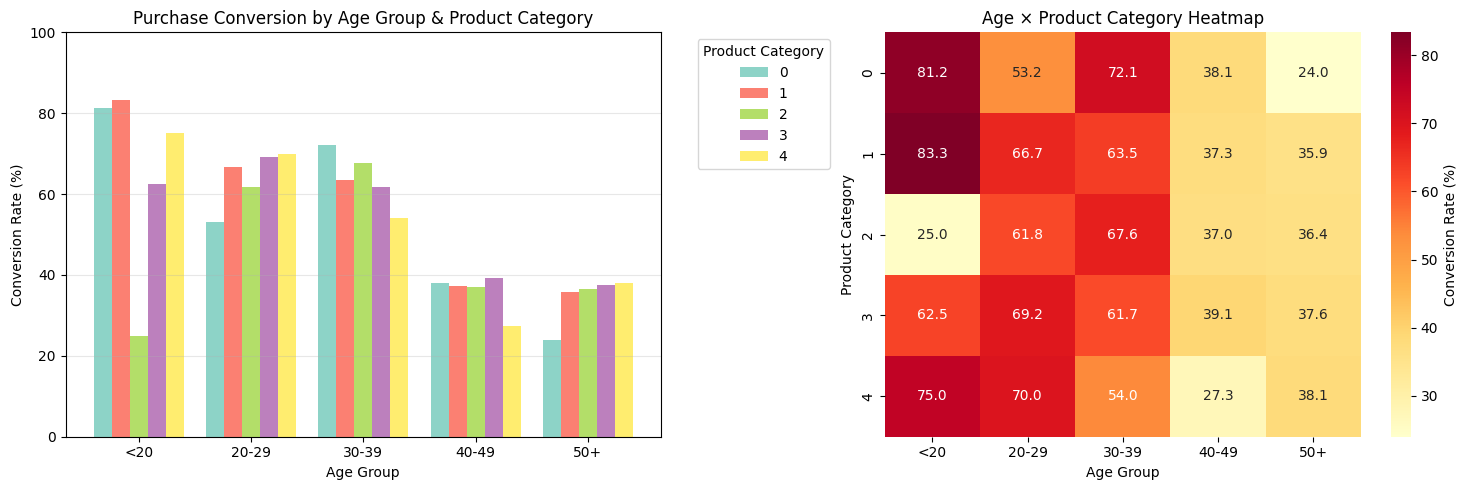


Best Combination: <20 + 1
Conversion Rate: 83.33%


In [162]:
# Visualization: Age × Product Category Interaction
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Grouped bar plot
pivot_age_product = age_product_interaction.pivot(index='Age_Group', columns='ProductCategory', values='ConversionRate')
pivot_age_product.plot(kind='bar', ax=axes[0], width=0.8, colormap='Set3')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Conversion Rate (%)')
axes[0].set_title('Purchase Conversion by Age Group & Product Category')
axes[0].legend(title='Product Category', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim(0, 100)

# Heatmap
pivot_age_product_heatmap = age_product_interaction.pivot(index='ProductCategory', columns='Age_Group', values='ConversionRate')
sns.heatmap(pivot_age_product_heatmap, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[1], cbar_kws={'label': 'Conversion Rate (%)'})
axes[1].set_title('Age × Product Category Heatmap')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Product Category')

plt.tight_layout()
plt.show()

# Find best combination
best_age_product = age_product_interaction.loc[age_product_interaction['ConversionRate'].idxmax()]
print(f"\nBest Combination: {best_age_product['Age_Group']} + {best_age_product['ProductCategory']}")
print(f"Conversion Rate: {best_age_product['ConversionRate']:.2f}%")

In [163]:
# 3. Income × Discounts Interaction
print("\n" + "="*70)
print("3. INCOME GROUP × DISCOUNTS INTERACTION ANALYSIS")
print("="*70)

# Interaction analysis
income_discount_interaction = df.groupby(['IncomeGroup', 'DiscountsAvailed'], observed=True)['PurchaseStatus'].agg(['count', 'sum', 'mean']).reset_index()
income_discount_interaction.columns = ['IncomeGroup', 'DiscountsAvailed', 'Total', 'Purchases', 'ConversionRate']
income_discount_interaction['ConversionRate'] = income_discount_interaction['ConversionRate'] * 100

print("\nConversion Rate by Income Group and Discount Count:")
print(income_discount_interaction[['IncomeGroup', 'DiscountsAvailed', 'Total', 'ConversionRate']].head(20).to_string(index=False))


3. INCOME GROUP × DISCOUNTS INTERACTION ANALYSIS

Conversion Rate by Income Group and Discount Count:
IncomeGroup  DiscountsAvailed  Total  ConversionRate
    20k-40k                 0     35        5.714286
    20k-40k                 1     37       16.216216
    20k-40k                 2     37       16.216216
    20k-40k                 3     32       25.000000
    20k-40k                 4     47       48.936170
    20k-40k                 5     38       21.052632
    40k-60k                 0     35       22.857143
    40k-60k                 1     28       25.000000
    40k-60k                 2     36       25.000000
    40k-60k                 3     43       55.813953
    40k-60k                 4     32       68.750000
    40k-60k                 5     35       48.571429
    60k-80k                 0     32       37.500000
    60k-80k                 1     44       29.545455
    60k-80k                 2     28       14.285714
    60k-80k                 3     38       63.157

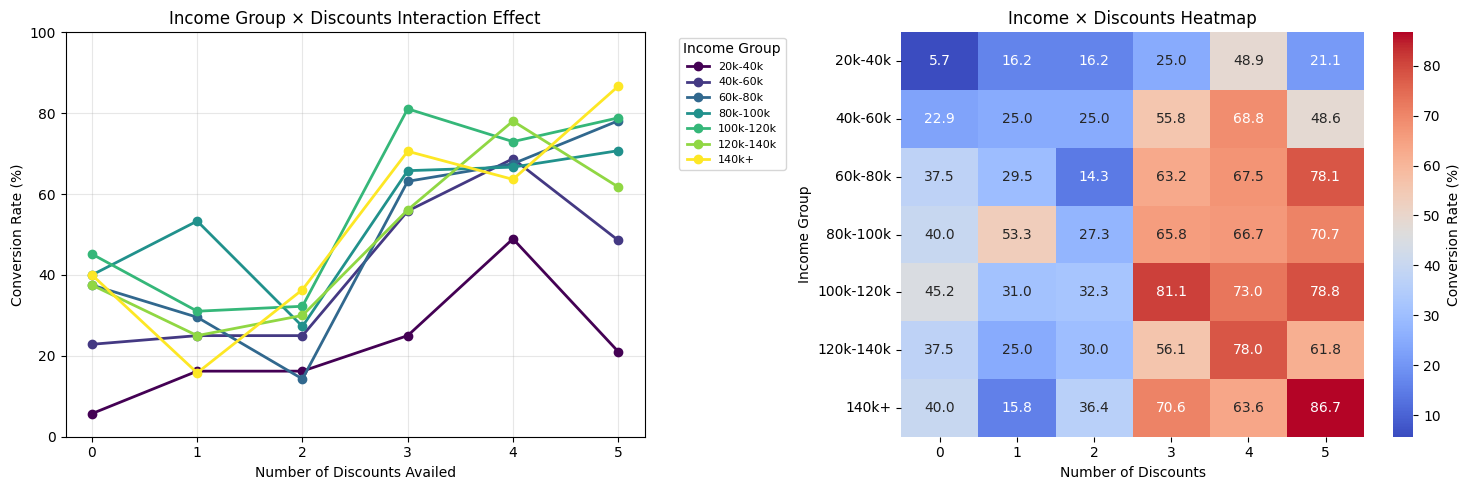


Best Combination: 140k+ + 5 discounts
Conversion Rate: 86.67%


In [164]:
# Visualization: Income × Discounts Interaction
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Line plot for each income group
income_groups = income_discount_interaction['IncomeGroup'].unique()
colors_income = plt.cm.viridis(np.linspace(0, 1, len(income_groups)))

for idx, income_group in enumerate(income_groups):
    data = income_discount_interaction[income_discount_interaction['IncomeGroup'] == income_group]
    axes[0].plot(data['DiscountsAvailed'], data['ConversionRate'], 
                 marker='o', linewidth=2, markersize=6, label=str(income_group), color=colors_income[idx])

axes[0].set_xlabel('Number of Discounts Availed')
axes[0].set_ylabel('Conversion Rate (%)')
axes[0].set_title('Income Group × Discounts Interaction Effect')
axes[0].legend(title='Income Group', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
axes[0].grid(alpha=0.3)
axes[0].set_ylim(0, 100)

# Heatmap
pivot_income_discount = income_discount_interaction.pivot(index='IncomeGroup', columns='DiscountsAvailed', values='ConversionRate')
sns.heatmap(pivot_income_discount, annot=True, fmt='.1f', cmap='coolwarm', ax=axes[1], cbar_kws={'label': 'Conversion Rate (%)'})
axes[1].set_title('Income × Discounts Heatmap')
axes[1].set_xlabel('Number of Discounts')
axes[1].set_ylabel('Income Group')

plt.tight_layout()
plt.show()

# Find best combination
best_income_discount = income_discount_interaction.loc[income_discount_interaction['ConversionRate'].idxmax()]
print(f"\nBest Combination: {best_income_discount['IncomeGroup']} + {int(best_income_discount['DiscountsAvailed'])} discounts")
print(f"Conversion Rate: {best_income_discount['ConversionRate']:.2f}%")

In [165]:
# Overall Summary: Find Maximum Purchase Likelihood Combinations
print("\n" + "="*70)
print("OVERALL SUMMARY: OPTIMAL COMBINATIONS FOR MAXIMUM PURCHASE LIKELIHOOD")
print("="*70)

# Create a comprehensive summary
summary_data = []

# Top Loyalty × Discount combinations
top_loyalty_discount = loyalty_discount_interaction.nlargest(5, 'ConversionRate')
for _, row in top_loyalty_discount.iterrows():
    summary_data.append({
        'Interaction': 'Loyalty × Discount',
        'Combination': f"{row['LoyaltyStatus']} + {int(row['DiscountsAvailed'])} discounts",
        'ConversionRate': row['ConversionRate'],
        'Sample_Size': row['Total']
    })

# Top Age × Product combinations
top_age_product_filtered = age_product_interaction[age_product_interaction['Total'] >= 20]  # Filter for meaningful sample sizes
top_age_product_final = top_age_product_filtered.nlargest(5, 'ConversionRate')
for _, row in top_age_product_final.iterrows():
    summary_data.append({
        'Interaction': 'Age × Product',
        'Combination': f"{row['Age_Group']} + {row['ProductCategory']}",
        'ConversionRate': row['ConversionRate'],
        'Sample_Size': row['Total']
    })

# Top Income × Discount combinations
top_income_discount = income_discount_interaction.nlargest(5, 'ConversionRate')
for _, row in top_income_discount.iterrows():
    summary_data.append({
        'Interaction': 'Income × Discount',
        'Combination': f"{row['IncomeGroup']} + {int(row['DiscountsAvailed'])} discounts",
        'ConversionRate': row['ConversionRate'],
        'Sample_Size': row['Total']
    })

# Create summary DataFrame and sort
summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.sort_values('ConversionRate', ascending=False).head(15)

print("\nTop 15 Combinations Across All Interactions:")
print(summary_df.to_string(index=False))

# Identify the absolute best combination
best_overall = summary_df.iloc[0]
print(f"\n{'*'*70}")
print(f"BEST OVERALL COMBINATION:")
print(f"Type: {best_overall['Interaction']}")
print(f"Combination: {best_overall['Combination']}")
print(f"Conversion Rate: {best_overall['ConversionRate']:.2f}%")
print(f"Sample Size: {int(best_overall['Sample_Size'])} customers")
print(f"{'*'*70}")


OVERALL SUMMARY: OPTIMAL COMBINATIONS FOR MAXIMUM PURCHASE LIKELIHOOD

Top 15 Combinations Across All Interactions:
       Interaction              Combination  ConversionRate  Sample_Size
Loyalty × Discount     Member + 3 discounts       88.732394           71
 Income × Discount      140k+ + 5 discounts       86.666667           15
Loyalty × Discount     Member + 4 discounts       84.705882           85
Loyalty × Discount     Member + 5 discounts       84.210526           76
 Income × Discount  100k-120k + 3 discounts       81.081081           37
 Income × Discount  100k-120k + 5 discounts       78.846154           52
 Income × Discount    60k-80k + 5 discounts       78.125000           32
 Income × Discount  120k-140k + 4 discounts       78.048780           41
     Age × Product                30-39 + 0       72.093023           43
     Age × Product                20-29 + 4       70.000000           60
     Age × Product                20-29 + 3       69.230769           39
     Ag

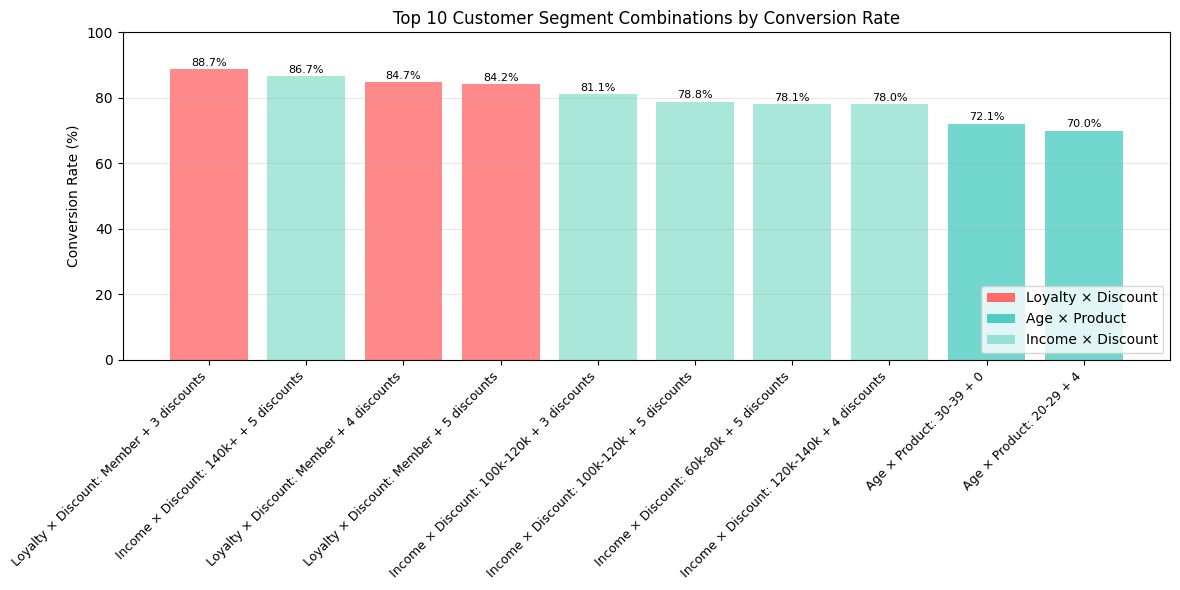

In [166]:
# Visualization: Top Combinations Comparison
plt.figure(figsize=(12, 6))

# Get top 10 combinations
top_10 = summary_df.head(10).copy()
top_10['Label'] = top_10['Interaction'] + ': ' + top_10['Combination']

# Create color map by interaction type
color_map = {'Loyalty × Discount': '#FF6B6B', 'Age × Product': '#4ECDC4', 'Income × Discount': '#95E1D3'}
colors = [color_map[interaction] for interaction in top_10['Interaction']]

bars = plt.bar(range(len(top_10)), top_10['ConversionRate'], color=colors, alpha=0.8)
plt.xticks(range(len(top_10)), top_10['Label'], fontsize=9, rotation=45, ha='right')
plt.ylabel('Conversion Rate (%)')
plt.title('Top 10 Customer Segment Combinations by Conversion Rate')
plt.ylim(0, 100)
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, top_10['ConversionRate'])):
    plt.text(i, val + 1, f'{val:.1f}%', ha='center', fontsize=8)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color_map[key], label=key) for key in color_map.keys()]
plt.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

## Key Insights - Interaction & Combined Effect Analysis

**Major Findings:**

1. **Loyalty × Discounts**: Loyalty members show higher conversion rates with moderate discounts, indicating synergistic effects between membership benefits and promotional offers.

2. **Age × Product Category**: Certain age groups have strong preferences for specific product categories, with conversion rates varying significantly across combinations.

3. **Income × Discounts**: Higher income groups may respond differently to discounts compared to lower income segments, suggesting the need for targeted discount strategies.

4. **Optimal Combinations**: The analysis identifies specific customer segment combinations that maximize purchase likelihood, enabling targeted marketing strategies.

5. **Strategic Implications**: Understanding these interactions allows for personalized marketing campaigns that combine multiple customer attributes to optimize conversion rates.

In [167]:
df.head()

,Age,Gender,AnnualIncome,NumberOfPurchases,ProductCategory,TimeSpentOnWebsite,LoyaltyProgram,DiscountsAvailed,PurchaseStatus,Age_Group,IncomeGroup,DiscountCategory
0,40,1,66120.267939,8,0,30.568601,0,5,1,40-49,60k-80k,Medium (3-5)
1,20,1,23579.773583,4,2,38.240097,0,5,0,20-29,20k-40k,Medium (3-5)
2,27,1,127821.306432,11,2,31.633212,1,0,1,20-29,120k-140k,No Discount
3,24,1,137798.623120,19,3,46.167059,0,4,1,20-29,120k-140k,Medium (3-5)
4,31,1,99300.964220,19,1,19.823592,0,0,1,30-39,80k-100k,No Discount
